Research question: To what extent can AI help in targeting public policies?


Scope 

Timeframe: 2011,2012 – 2021 

Emissions scope: CO2e for utilities of residential sector and small and medium indistry, on-road transportation

In [60]:
#import libraries
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [61]:
#load the community emissions dataset as csv file
utility_emissions = pd.read_csv('../data/raw/utilities_new.csv')

#replace W's from emissions in wood with 0
utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'] = utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'].replace('W', 0)

# Display the first few rows of the utility emissions dataset
utility_emissions.head()

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,CONNECTION_TOTAL,EMISSIONS NET IMPORTS (TCO2e),Unnamed: 12,Unnamed: 13,Unnamed: 14
0,2022,BC Hydro,11080,5909052,Abbotsford,1005909,ELEC,kWh,Res,538127235.5,48760,6187.602205,2022ELECkWh,NaN,NaN
1,2022,BC Hydro,11080,1005923,Alberni-Clayoquot,9000000,ELEC,kWh,Res,226116610.6,17311,2599.979236,2022ELECkWh,NaN,NaN
2,2022,BC Hydro,11080,2005923,Alberni-Clayoquot Unincorporated Areas,1005923,ELEC,kWh,Res,79348847.45,5601,912.3847875,2022ELECkWh,NaN,NaN
3,2022,BC Hydro,11080,5943008,Alert Bay,1005943,ELEC,kWh,Res,3775260.192,275,43.40945179,2022ELECkWh,NaN,NaN
4,2022,BC Hydro,11080,5915038,Anmore,1005915,ELEC,kWh,Res,14323873.26,773,164.7016243,2022ELECkWh,NaN,NaN


In [62]:
# load the transportation emissions dataset as csv file
transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')
transportation_emissions.head()


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/1375076493.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
0,5909052,Abbotsford,1005909,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,1.00,11734.493600,5890.715786,8.010833,NaN
1,5915038,Anmore,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.89,9240.491799,4638.726883,6.308712,NaN
2,5933019,Ashcroft,1005933,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.76,7890.757042,3961.160035,5.388842,NaN
3,5915036,Belcarra,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.00,0.000000,0.000000,0.000000,NaN
4,2005951,Bulkley-Nechako Unincorporated Areas,1005951,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.11,1142.083256,573.325795,0.778630,NaN


In [63]:
#list of regional districts including typos in datasets
bc_regional_districts = [
    "Alberni-Clayoquot",
    "Bulkley-Nechako",
    "Capital",
    "Cariboo",
    "Central Coast",
    "Central Kootenay",
    "Central Okanagan",
    "Columbia-Shuswap",
    "Comox Valley",
    "Cowichan Valley",
    "East Kootenay",
    "Fraser Valley",
    "Fraser-Fort George",
    "Greater Vancouver",
    "Islands Trust",
    "Kitimat-Stikine",
    "Kootenay Boundary",
    "Metro-Vancouver",
    "Mount Waddington",
    "Nanaimo RD",
    "North Okanagan",
    "Northern Rockies RD",
    "Okanagan-Similkameen",
    "Peace River",
    "qathet",
    "Skeena-Queen Charlotte",
    "Squamish-Lillooet",
    "Stikine",
    "Sitkine", #the typo in the datasets is "Sitkine" instead of "Stikine"
    "Strathcona",
    "Sunshine Coast",
    "Thompson-Nicola"
]
#list of unincorporated areas
list_of_unincorporated_areas = [
    "Alberni-Clayoquot Unincorporated Areas",
    "Bulkley-Nechako Unincorporated Areas",
    "Capital Unincorporated Areas",
    "Cariboo Unincorporated Areas",
    "Central Coast Unincorporated Areas",
    "Central Kootenay Unincorporated Areas",
    "Central Okanagan Unincorporated Areas",
    "Columbia-Shuswap Unincorporated Areas",
    "Comox Valley Unincorporated Areas",
    "Comox Unincorporated Areas",
    "Cowichan Valley Unincorporated Areas",
    "East Kootenay Unincorporated Areas",
    "Fraser Valley Unincorporated Areas",
    "Fraser-Fort George Unincorporated Areas",
    "Greater Vancouver Unincorporated Areas",
    "Islands Trust Unincorporated Areas",
    "Kitimat-Stikine Unincorporated Areas",
    "Kootenay Boundary Unincorporated Areas",
    "Metro-Vancouver Unincorporated Areas",
    "Mount Waddington Unincorporated Areas",
    "Nanaimo Unincorporated Areas",
    "Northern Rockies Unincorporated Areas", #check if there are variations to this, like Northern Rockies Regional Municipality Unincorporated Areas
    "Skeena-Queen Charlotte Unincorporated Areas",
    "North Okanagan Unincorporated Areas",
    "Okanagan-Similkameen Unincorporated Areas",
    "Peace River Unincorporated Areas",
    "Powell River Unincorporated Areas",
    "qathet Unincorporated Areas",
    "Squamish-Lillooet Unincorporated Areas",
    "Stikine Unincorporated Areas",
    "Sitkine Unincorporated Areas",
    "Sunshine Coast Unincorporated Areas",
    "Strathcona Unincorporated Areas",
    "Thompson-Nicola Unincorporated Areas"
]


province = ["British Columbia"]

Indigenous= ["Sechelt IGD", "Sechelt Ind Gov Dist (Part-Powell River)", "Sechelt Ind Gov Dist"]

#four_std_dev_outliers = ["Warfield", "Elkford", "Burns Lake", "Kaslo", "Telkwa", "Highlands", "Invermere", "Squamish", "Burnaby"]

#outliers_clustering = ["Comox", "Elkford", "Powell River"]

population_below_250 = ["Hazelton", "Lytton", "Silverton", "Wells", "Zeballos", "Tahsis"]

not_in_2006_cwb = ["Slocan", "Barriere", "Clearwater", "Sun Peaks Mountain Resort", "Sun Peaks Mountain", "West Kelowna",  "Northern Rockies", "Northern Rockies Regional Municipality" ,"Norther Rockies Regional Municipality"]

data_lacking = ['Tofino'] #In Tofino, no residential polluting energy means no polluting emissions factor can be calculated ( emissions = 0 / energy = 0 is undefined) -> however, total residentail emissions factors can still be calculated because electricity use is non-zero

exclusions_list = (list_of_unincorporated_areas 
                                                  + bc_regional_districts 
                                                  + province 
                                                  + not_in_2006_cwb 
                                                  + population_below_250 
                                                  + Indigenous
                                                  + data_lacking
                                                  #+ outliers_clustering
                                                  #+ four_std_dev_outliers
                                                  )

#list of years
years_transportation_co2 = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_buildings_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_waste_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

In [64]:
#select municipalities from the utility emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~utility_emissions['ORG_NAME'].isin(exclusions_list)
                                           
utility_df = utility_emissions[mask]
#print(utility_df['ORG_NAME'].unique())
#save the utility_df to a csv file in the data/processed folder
utility_df.to_csv(os.path.join('..','data','processed','municipalities_utility_emissions.csv'), index=False)
utility_df.head()

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,CONNECTION_TOTAL,EMISSIONS NET IMPORTS (TCO2e),Unnamed: 12,Unnamed: 13,Unnamed: 14
0,2022,BC Hydro,11080,5909052,Abbotsford,1005909,ELEC,kWh,Res,538127235.5,48760,6187.602205,2022ELECkWh,NaN,NaN
3,2022,BC Hydro,11080,5943008,Alert Bay,1005943,ELEC,kWh,Res,3775260.192,275,43.40945179,2022ELECkWh,NaN,NaN
4,2022,BC Hydro,11080,5915038,Anmore,1005915,ELEC,kWh,Res,14323873.26,773,164.7016243,2022ELECkWh,NaN,NaN
5,2022,BC Hydro,11080,5937028,Armstrong,1005937,ELEC,kWh,Res,21935314.26,2408,252.2210175,2022ELECkWh,NaN,NaN
6,2022,BC Hydro,11080,5933019,Ashcroft,1005933,ELEC,kWh,Res,7649213.599,940,87.95371765,2022ELECkWh,NaN,NaN


In [65]:

# Remove commas from the values, then convert to numeric
utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = utility_df['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
#remove 'W' from the values and convert to numeric, filling NaN with 0
utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_df['EMISSIONS NET IMPORTS (TCO2e)'], errors='coerce').fillna(0)

# Remove commas from the values, then convert to numeric
utility_df['CONSUMPTION_TOTAL'] = utility_df['CONSUMPTION_TOTAL'].astype(str).str.replace(',', '')
#remove 'W' from the values and convert to numeric, filling NaN with 0
utility_df['CONSUMPTION_TOTAL'] = pd.to_numeric(utility_df['CONSUMPTION_TOTAL'], errors='coerce').fillna(0)


#correct norther rockies to northern rockies -> in the end it doesn't matter since I exclude this municipality
utility_df['ORG_NAME'] = utility_df['ORG_NAME'].str.replace('Norther Rockies Regional Municipality', 'Northern Rockies Regional Municipality')
utility_df['ORG_NAME'] = utility_df['ORG_NAME'].str.replace('Northern Rockies Regional Municipality', 'Northern Rockies')

#remove summerland's fortis electric values under "source" in utility_df but keep the city_of_summerland values
utility_df = utility_df[~((utility_df['ORG_NAME'] == 'Summerland') & (utility_df['SOURCE'] == 'Fortis Electric'))]

#replace BC Hydro residential electricity values for 2020 with 21533683 and csmi with 20119061 and estimate emissions
utility_df.loc[(utility_df['ORG_NAME']=="Tofino") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONSUMPTION_TOTAL'] = 21533683
utility_df.loc[(utility_df['ORG_NAME']=="Tofino") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONNECTION_TOTAL'] = 1315
utility_df.loc[(utility_df['ORG_NAME']=="Tofino") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'EMISSIONS NET IMPORTS (TOC2e)'] = 230

#replace Taylor's values for 2020 residential data and CSMI data
utility_df.loc[(utility_df['ORG_NAME']=="Taylor") & (utility_df['SOURCE']=="Pacific Northern Gas") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONSUMPTION_TOTAL'] = 56508
utility_df.loc[(utility_df['ORG_NAME']=="Taylor") & (utility_df['SOURCE']=="Pacific Northern Gas") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONNECTION_TOTAL'] = 528
utility_df.loc[(utility_df['ORG_NAME']=="Taylor") & (utility_df['SOURCE']=="Pacific Northern Gas") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'EMISSIONS NET IMPORTS (TOC2e)'] = 2845
utility_df.loc[(utility_df['ORG_NAME']=="Taylor") & (utility_df['SOURCE']=="Pacific Northern Gas") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="CSMI"), 'CONSUMPTION_TOTAL'] = 22756
utility_df.loc[(utility_df['ORG_NAME']=="Taylor") & (utility_df['SOURCE']=="Pacific Northern Gas") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="CSMI"), 'EMISSIONS NET IMPORTS (TOC2e)'] = 1146


utility_df.loc[(utility_df['ORG_NAME']=="Port Alberni") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONSUMPTION_TOTAL'] = 96371327 
utility_df.loc[(utility_df['ORG_NAME']=="Port Alberni") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONNECTION_TOTAL'] = 8739 
utility_df.loc[(utility_df['ORG_NAME']=="Port Alberni") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'EMISSIONS NET IMPORTS (TOC2e)'] = 3775 


#drop all datapoints for 2022 in utility dataset since some of them had problems anyways
utility_df = utility_df[utility_df['YEAR'] != 2022]
#drop all "MIXED" in the utility dataset
utility_df = utility_df[utility_df['SUB_SECTOR'] != "MIXED"]




/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/2334838542.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = utility_df['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/2334838542.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_df['EMISSIONS NET IMPORTS (TCO2e)'], errors='coerce').fillna(0)
/

In [66]:
#count how many org names show up when we filter the ones that are within CSMI and supplied by fortis electric, fortis electric, and pacific northern gas
CSMI_fortis_pcng = utility_df[
    (utility_df["SUB_SECTOR"] == "CSMI") & 
    (utility_df["SOURCE"].isin(["Fortis Electric", "Fortis Gas", "Pacific Northern Gas"]))
]

In [67]:
print(CSMI_fortis_pcng["ORG_NAME"].nunique())


119


In [68]:
# List of sources to exclude from interpolation for the year 2013
excluded_sources = [
    'BC Hydro', 
    'Fortis Electric', 
    'Fortis Gas', 
    'Pacific Northern Gas',
    'Estimate-Heating Oil',
    'Estimate-Propane',
    'Estimate-Wood'
]

df = utility_df.copy()
# Get sources that need interpolation
sources_to_interpolate = df[~df['SOURCE'].isin(excluded_sources)]['SOURCE'].unique()

# List to store new interpolated rows
interpolated_rows = []

# Iterate through each source that needs interpolation
for source in sources_to_interpolate:
    # Get data for this source in 2012 and 2014
    data_2012 = df[(df['YEAR'] == 2012) & (df['SOURCE'] == source)]
    data_2014 = df[(df['YEAR'] == 2014) & (df['SOURCE'] == source)]
    
    # Get unique ORG_NAMEs that exist in both 2012 and 2014
    org_names_2012 = set(data_2012['ORG_NAME'].unique())
    org_names_2014 = set(data_2014['ORG_NAME'].unique())
    common_org_names = org_names_2012.intersection(org_names_2014)
    
    # For each ORG_NAME
    for org_name in common_org_names:
        # Get data for this ORG_NAME
        org_data_2012 = data_2012[data_2012['ORG_NAME'] == org_name]
        org_data_2014 = data_2014[data_2014['ORG_NAME'] == org_name]
        
        # Get unique ENERGY_TYPEs for this ORG_NAME in both years
        energy_types_2012 = set(org_data_2012['ENERGY_TYPE'].unique())
        energy_types_2014 = set(org_data_2014['ENERGY_TYPE'].unique())
        common_energy_types = energy_types_2012.intersection(energy_types_2014)
        
        # For each ENERGY_TYPE
        for energy_type in common_energy_types:
            # Get data for this ENERGY_TYPE
            energy_data_2012 = org_data_2012[org_data_2012['ENERGY_TYPE'] == energy_type]
            energy_data_2014 = org_data_2014[org_data_2014['ENERGY_TYPE'] == energy_type]
            
            # Get unique SUB_SECTORs for this ENERGY_TYPE in both years
            sub_sectors_2012 = set(energy_data_2012['SUB_SECTOR'].unique())
            sub_sectors_2014 = set(energy_data_2014['SUB_SECTOR'].unique())
            common_sub_sectors = sub_sectors_2012.intersection(sub_sectors_2014)
            
            # For each SUB_SECTOR
            for sub_sector in common_sub_sectors:
                # Get the specific rows for 2012 and 2014
                row_2012 = energy_data_2012[energy_data_2012['SUB_SECTOR'] == sub_sector]
                row_2014 = energy_data_2014[energy_data_2014['SUB_SECTOR'] == sub_sector]
                
                if not row_2012.empty and not row_2014.empty:
                    # Take the first row if there are multiple (shouldn't happen with unique combination)
                    row_2012 = row_2012.iloc[0]
                    row_2014 = row_2014.iloc[0]
                    
                    # Get values for interpolation
                    consumption_2012 = float(row_2012['CONSUMPTION_TOTAL']) if pd.notna(row_2012['CONSUMPTION_TOTAL']) else 0
                    consumption_2014 = float(row_2014['CONSUMPTION_TOTAL']) if pd.notna(row_2014['CONSUMPTION_TOTAL']) else 0
                    
                    connection_2012 = float(row_2012['CONNECTION_TOTAL']) if pd.notna(row_2012['CONNECTION_TOTAL']) else 0
                    connection_2014 = float(row_2014['CONNECTION_TOTAL']) if pd.notna(row_2014['CONNECTION_TOTAL']) else 0
                    
                    emissions_2012 = float(row_2012['EMISSIONS NET IMPORTS (TCO2e)']) if pd.notna(row_2012['EMISSIONS NET IMPORTS (TCO2e)']) else 0
                    emissions_2014 = float(row_2014['EMISSIONS NET IMPORTS (TCO2e)']) if pd.notna(row_2014['EMISSIONS NET IMPORTS (TCO2e)']) else 0
                    
                    # Calculate averages for interpolation
                    consumption_2013 = (consumption_2012 + consumption_2014) / 2
                    connection_2013 = (connection_2012 + connection_2014) / 2
                    emissions_2013 = (emissions_2012 + emissions_2014) / 2
                    
                    # Create new row for 2013
                    new_row = {
                        'YEAR': 2013,
                        'SOURCE': source,
                        'Data Source ID': '20122014',  # Symbolic value for interpolation
                        'ORG_UNIT': row_2012['ORG_UNIT'],  # Keep same ORG_UNIT
                        'ORG_NAME': org_name,
                        'ORG_PART': row_2012['ORG_PART'],  # Keep same ORG_PART
                        'ENERGY_TYPE': energy_type,
                        'ENERGY_UNIT': row_2012['ENERGY_UNIT'],  # Keep same ENERGY_UNIT
                        'SUB_SECTOR': sub_sector,
                        'CONSUMPTION_TOTAL': consumption_2013,
                        'CONNECTION_TOTAL': connection_2013,
                        'EMISSIONS NET IMPORTS (TCO2e)': emissions_2013
                    }
                    
                    interpolated_rows.append(new_row)


# Add interpolated rows to the dataframe
if interpolated_rows:
    df_interpolated = pd.DataFrame(interpolated_rows)
    utility_df = pd.concat([utility_df, df_interpolated], ignore_index=True)
    
    # Sort by year and other columns for better organization
    utility_df = utility_df.sort_values(['YEAR', 'SOURCE', 'ORG_NAME', 'ENERGY_TYPE']).reset_index(drop=True)
    
    print(f"Successfully added {len(interpolated_rows)} interpolated rows for 2013")
    print(f"\nSources interpolated: {sorted(set([row['SOURCE'] for row in interpolated_rows]))}")
    
    # Show sample of interpolated data
    print("\nSample of interpolated 2013 data:")
    sample_df = utility_df[(utility_df['YEAR'] == 2013) & (utility_df['Data Source ID'] == '20122014')].head(5)
    print(sample_df[['YEAR', 'SOURCE', 'ORG_NAME', 'ENERGY_TYPE', 'CONSUMPTION_TOTAL', 'CONNECTION_TOTAL', 'EMISSIONS NET IMPORTS (TCO2e)']])
else:
    print("No rows needed interpolation based on the criteria")

# Verify by checking a specific example
if interpolated_rows:
    # Pick first interpolated source for verification
    sample_source = interpolated_rows[0]['SOURCE']
    sample_org = interpolated_rows[0]['ORG_NAME']
    sample_energy = interpolated_rows[0]['ENERGY_TYPE']
    
    print(f"\nVerification for {sample_source}, {sample_org}, {sample_energy}:")
    verification_df = utility_df[
        (utility_df['SOURCE'] == sample_source) & 
        (utility_df['ORG_NAME'] == sample_org) & 
        (utility_df['ENERGY_TYPE'] == sample_energy) &
        (utility_df['YEAR'].isin([2012, 2013, 2014]))
    ]
    print(verification_df[['YEAR', 'CONSUMPTION_TOTAL', 'CONNECTION_TOTAL', 'EMISSIONS NET IMPORTS (TCO2e)']])

Successfully added 13 interpolated rows for 2013

Sources interpolated: ['Cal-gas', 'City of Grand Forks', 'City of Penticton ', 'City of Summerland ', 'Nelson Electric', 'New Westminster Electrical Utility', 'Port Alice Gas']

Sample of interpolated 2013 data:
      YEAR               SOURCE     ORG_NAME ENERGY_TYPE  CONSUMPTION_TOTAL  \
3244  2013              Cal-gas       Golden        PPRO             1341.0   
3245  2013  City of Grand Forks  Grand Forks        ELEC         18297239.5   
3246  2013  City of Grand Forks  Grand Forks        ELEC         20804040.5   
3247  2013   City of Penticton     Penticton        ELEC        185936070.0   
3248  2013   City of Penticton     Penticton        ELEC        157808290.0   

     CONNECTION_TOTAL  EMISSIONS NET IMPORTS (TCO2e)  
3244             24.0                      81.657514  
3245           1879.0                     463.659635  
3246            322.5                     531.354733  
3247          15446.5                    47

In [69]:
# Group by YEAR and ORG_NAME, summing the emissions
total_utility_emissions = utility_df.groupby(
    ['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()

#save to csv file in the data/processed folder
total_utility_emissions.to_csv(os.path.join('..','data','processed','total_utility_emissions.csv'), index=False)
total_utility_emissions.tail()


,YEAR,ORG_NAME,EMISSIONS NET IMPORTS (TCO2e)
1759,2021,Warfield,3222.315145
1760,2021,West Vancouver,138127.678209
1761,2021,Whistler,54430.956601
1762,2021,White Rock,41192.637901
1763,2021,Williams Lake,88545.047895


In [70]:
print ("\nTotal utility emissions for each community:")
# Display the total utility emissions for each community
print(total_utility_emissions)


Total utility emissions for each community:
      YEAR        ORG_NAME  EMISSIONS NET IMPORTS (TCO2e)
0     2007      Abbotsford                  369133.300024
1     2007       Alert Bay                     835.510099
2     2007          Anmore                    4442.247271
3     2007       Armstrong                   11999.055741
4     2007        Ashcroft                   14440.813090
...    ...             ...                            ...
1759  2021        Warfield                    3222.315145
1760  2021  West Vancouver                  138127.678209
1761  2021        Whistler                   54430.956601
1762  2021      White Rock                   41192.637901
1763  2021   Williams Lake                   88545.047895

[1764 rows x 3 columns]


In [71]:
#select municipalities from the transportation emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~transportation_emissions['ORG_NAME'].isin(exclusions_list)
transportation_df = transportation_emissions[mask]

#change names of communities to match the utility_df
# Greater Vancouver -> Metro Vancouver
# Sun Peaks Mountain -> Sun Peaks Mountain Resort
# Sechelt District Municipality -> Sechelt

transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({
    "Greater Vancouver": "Metro Vancouver",
    "Sun Peaks Mountain": "Sun Peaks Mountain Resort",
    "Sechelt District Municipality": "Sechelt",
    "Sechelt Ind Gov Dist (Part-Powell River)": "Sechelt IGD",
    "Sechelt Ind Gov Dist": "Sechelt IGD"
})
transportation_df.to_csv(os.path.join('..','data','processed','municipalities_transportation_emissions.csv'), index=False)
#transportation_df.head()
#print(transportation_df['ORG_NAME'].unique())

#drop all datapoints for 2022 in transportation dataset
transportation_df = transportation_df[transportation_df['Year'] != 2022]

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/828340208.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({


In [72]:
#for each year and each community, calculate the total emissions for that community by summing the emissions for values in all vehicle fuel categories

# Group by 'YEAR' and 'ORG_NAME' and sum the emissions
total_transportation_emissions = transportation_df.groupby(['Year', 'ORG_NAME'], as_index=False)['Emissions tCO2e'].sum()

#save to csv file in the data/processed folder
total_transportation_emissions.to_csv(os.path.join('..','data','processed','total_transportation_emissions.csv'), index=False)

In [73]:
print("Unique organizations in total_emissions:")
#print(total_transportation_emissions['ORG_NAME'].unique())

Unique organizations in total_emissions:


In [74]:
print ("\nTotal transportation emissions for each community:")
# Display the total transportation emissions for each community
#total_emissions.head()
#print(total_transportation_emissions)


Total transportation emissions for each community:


In [75]:
transportation_emissions_communities_list = set(total_transportation_emissions['ORG_NAME'])
utility_emissions_communities_list = set(total_utility_emissions['ORG_NAME'])
# Find communities that are in transportation emissions but not in utility emissions
missing_communities = transportation_emissions_communities_list - utility_emissions_communities_list
print("\nCommunities in transportation emissions but not in utility emissions:")
print(missing_communities)
# Find communities that are in utility emissions but not in transportation emissions
missing_communities = utility_emissions_communities_list - transportation_emissions_communities_list
print("\nCommunities in utility emissions but not in transportation emissions:")
print(missing_communities)


Communities in transportation emissions but not in utility emissions:
set()

Communities in utility emissions but not in transportation emissions:
set()


In [76]:
#open CWB_2021 and CWB_2011 from the data folder/raw
# Load the dataset
cwb_2021 = pd.read_csv(os.path.join('..','data','raw','CWB_2021.csv'),encoding='latin-1')
cwb_2016 = pd.read_csv(os.path.join('..','data','raw','CWB_2016.csv'))
cwb_2011 = pd.read_csv(os.path.join('..','data','raw','CWB_2011.csv'),encoding='latin-1')
cwb_2006 = pd.read_csv(os.path.join('..','data','raw','CWB_2006.csv'),encoding='latin-1')
# Display the first few rows of each dataset
print("CWB_2021 dataset:")
print(cwb_2021.head())

print("\n CWB_2016_dataset:")
print(cwb_2016.head())

print("\n CWB_2011_dataset:")
print(cwb_2011.head())

print("\n CWB_2006_dataset:")
print(cwb_2006.head())

CWB_2021 dataset:
   CSD Code 2021             CSD Name 2021  Census Population 2021  \
0        1001101  Division No.  1, Subd. V                    55.0   
1        1001105       Portugal Cove South                    86.0   
2        1001113                 Trepassey                   405.0   
3        1001120               St. Shott's                    55.0   
4        1001124  Division No.  1, Subd. U                  1373.0   

   Income 2021  Education 2021  Housing 2021  Labour Force Activity 2021  \
0          NaN             NaN           NaN                         NaN   
1          NaN             NaN           NaN                         NaN   
2         76.0            48.0          97.0                        70.0   
3          NaN             NaN           NaN                         NaN   
4         81.0            63.0          98.0                        77.0   

   CWB 2021       Community Type 2021  
0       NaN  Non-Indigenous Community  
1      73.0  Non-Indigen

In [77]:
#replace the csd name "north vancouver" that has a csd code 5915046 in column one, to "north vancouver district municipality"
#replace the csd name "north vancouver" that has a csd code 5915051 in column one, to "north vancouver city"

# Replace 2021 North Vancouver entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915046, 'CSD Name 2021'] = 'North Vancouver District'
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915051, 'CSD Name 2021'] = 'North Vancouver City'

# Replace 2016 North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915046, 'CSD Name 2016'] = 'North Vancouver District'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915051, 'CSD Name 2016'] = 'North Vancouver City'

# Replace 2011North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915046, 'CSD Name 2011'] = 'North Vancouver District'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915051, 'CSD Name 2011'] = 'North Vancouver City'

# Replace 2006 North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915046, 'CSD Name 2006'] = 'North Vancouver District'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915051, 'CSD Name 2006'] = 'North Vancouver City'


#rename sun peaks mountain to sun peaks mountain resort in the cwb data
cwb_2021['CSD Name 2021'] = cwb_2021['CSD Name 2021'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2016['CSD Name 2016'] = cwb_2016['CSD Name 2016'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2011['CSD Name 2011'] = cwb_2011['CSD Name 2011'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2006['CSD Name 2006'] = cwb_2006['CSD Name 2006'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')


#replace the csd name "langley" that has a csd code 5915001 in column one, to "langley township"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915001, 'CSD Name 2021'] = 'Langley Township'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915001, 'CSD Name 2016'] = 'Langley Township'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915001, 'CSD Name 2011'] = 'Langley Township'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915001, 'CSD Name 2006'] = 'Langley Township'


#replace the csd name "langley" that has a csd code 5915002 in column one, to "langley city"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915002, 'CSD Name 2021'] = 'Langley City'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915002, 'CSD Name 2016'] = 'Langley City'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915002, 'CSD Name 2011'] = 'Langley City'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915002, 'CSD Name 2006'] = 'Langley City'


# Replace Sechelt (Part) entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5929803, 'CSD Name 2021'] = 'Sechelt IGD'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5929803, 'CSD Name 2016'] = 'Sechelt IGD'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5929803, 'CSD Name 2011'] = 'Sechelt IGD'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5929803, 'CSD Name 2006'] = 'Sechelt IGD'

#rename CSD Name / Nom de la SDR 2006 to CSD Name 2006
cwb_2006.rename(columns={'CSD Name 2006': 'CSD Name 2006'}, inplace=True)
#rename CSD Code / Code de la SDR 2006 to CSD Code 2006
cwb_2006.rename(columns={'CSD Code SDR 2006': 'CSD Code 2006'}, inplace=True)  

In [78]:
#remove cities with the same name in the wellbeing dataset that are not from BC

# Define the correct BC CSD codes
bc_csd_codes = {
    'Victoria': 5917034,
    'Richmond': 5915015,
    'Armstrong': 5937028,
    'Nelson': 5903015,
    'Kent': 5909032,
    'Hope': 5909009,
    'Esquimalt': 5917040,
    'Alert Bay': 5943008,
    'Langford' : 5917044,
}

# Remove duplicates by keeping only the BC CSD codes
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2021 = cwb_2021[~((cwb_2021['CSD Name 2021'] == city_name) & 
                          (cwb_2021['CSD Code 2021'] != correct_code))]

print("Removed duplicate cities from 2021 dataset")

# Remove duplicates from 2016 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2016 = cwb_2016[~((cwb_2016['CSD Name 2016'] == city_name) & 
                          (cwb_2016['CSD Code 2016'] != correct_code))]

print("Removed duplicate cities from 2016 dataset")

# Remove duplicates from 2011 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2011 = cwb_2011[~((cwb_2011['CSD Name 2011'] == city_name) & 
                          (cwb_2011['CSD Code 2011'] != correct_code))]

print("Removed duplicate cities from 2006 dataset")

# Remove duplicates from 2006 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2006 = cwb_2006[~((cwb_2006['CSD Name 2006'] == city_name) & 
                          (cwb_2006['CSD Code 2006'] != correct_code))]

print("Removed duplicate cities from 2006 dataset")

Removed duplicate cities from 2021 dataset
Removed duplicate cities from 2016 dataset
Removed duplicate cities from 2006 dataset
Removed duplicate cities from 2006 dataset


In [79]:
transportation_emissions_pivot = total_transportation_emissions.pivot(index='ORG_NAME', columns='Year', values='Emissions tCO2e')
utility_emissions_pivot = total_utility_emissions.pivot(index='ORG_NAME', columns='YEAR', values='EMISSIONS NET IMPORTS (TCO2e)')

In [80]:
# Get unique community names from each dataset as a list
transportation_emissions_communities = set(transportation_emissions_pivot.index)
wellbeing_2021_communities = set(cwb_2021['CSD Name 2021'].dropna())
wellbeing_2016_communities = set(cwb_2016['CSD Name 2016'].dropna())
wellbeing_2011_communities = set(cwb_2011['CSD Name 2011'].dropna())
wellbeing_2006_communities = set(cwb_2006['CSD Name 2006'].dropna())

# Find exact matches (as a list)
exact_matches_2021 = transportation_emissions_communities.intersection(wellbeing_2021_communities)
exact_matches_2016 = transportation_emissions_communities.intersection(wellbeing_2016_communities)
exact_matches_2011 = transportation_emissions_communities.intersection(wellbeing_2011_communities)
exact_matches_2006 = transportation_emissions_communities.intersection(wellbeing_2006_communities)
exact_matches_2021_2016_2011 = exact_matches_2021.intersection(exact_matches_2016).intersection(exact_matches_2011)

print(f"Exact matches with 2021 wellbeing: {len(exact_matches_2021)}")
print(f"Exact matches with 2016 wellbeing: {len(exact_matches_2016)}")
print(f"Exact matches with 2011 wellbeing: {len(exact_matches_2011)}")
print(f"Exact matches with 2006 wellbeing: {len(exact_matches_2006)}")
print(f"Exact matches with 2021, 2016, and 2011 wellbeing: {len(exact_matches_2021_2016_2011)}")
#print(f"Exact matches with both years: {len(exact_matches_both)}")

# Get unmatched communities by subtracting lists
unmatched_emissions_transp = transportation_emissions_communities - exact_matches_2006
unmatched_emissions_utility = set(utility_emissions_pivot.index) - exact_matches_2006

print("\nAll unmatched transportation communities:")
for community in sorted(list(unmatched_emissions_transp)):
    print(f"  {community}")

print("\nAll unmatched utility communities:")
for community in sorted(list(unmatched_emissions_utility)):
    print(f"  {community}")

Exact matches with 2021 wellbeing: 147
Exact matches with 2016 wellbeing: 147
Exact matches with 2011 wellbeing: 147
Exact matches with 2006 wellbeing: 147
Exact matches with 2021, 2016, and 2011 wellbeing: 147

All unmatched transportation communities:

All unmatched utility communities:


In [81]:
# Create new dataframes: Filter wellbeing datasets to only include matched communities in the list of exact matches
matched_cwb_2021 = cwb_2021[cwb_2021['CSD Name 2021'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2016 = cwb_2016[cwb_2016['CSD Name 2016'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2011 = cwb_2011[cwb_2011['CSD Name 2011'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2006 = cwb_2006[cwb_2006['CSD Name 2006'].isin(exact_matches_2021_2016_2011)].copy()

print(f"Filtered wellbeing data:")
print(f"  2021: {len(matched_cwb_2021)} communities")
print(f"  2016: {len(matched_cwb_2016)} communities")
print(f"  2011: {len(matched_cwb_2011)} communities")
print(f"  2006: {len(matched_cwb_2006)} communities")   

# Also filter emissions data to matched communities
matched_transportation_emissions = transportation_emissions_pivot[transportation_emissions_pivot.index.isin(exact_matches_2021_2016_2011)].copy()
print(f"  Transportation Emissions: {len(matched_transportation_emissions)} communities")

# Also filter emissions data to matched communities
matched_utility_emissions = utility_emissions_pivot[utility_emissions_pivot.index.isin(exact_matches_2021_2016_2011)].copy()
print(f"  Utility Emissions: {len(matched_utility_emissions)} communities")

Filtered wellbeing data:
  2021: 147 communities
  2016: 147 communities
  2011: 147 communities
  2006: 147 communities
  Transportation Emissions: 147 communities
  Utility Emissions: 147 communities


In [82]:
# Check for duplicate community names in wellbeing data
print("Duplicate community names in 2021 wellbeing data:")
duplicates_2021 = matched_cwb_2021[cwb_2021.duplicated('CSD Name 2021', keep=False)]['CSD Name 2021'].value_counts()
print(duplicates_2021)

print("\nDuplicate community names in 2011 wellbeing data:")
duplicates_2016 = matched_cwb_2016[cwb_2016.duplicated('CSD Name 2016', keep=False)]['CSD Name 2016'].value_counts()
print(duplicates_2016)

print("\nDuplicate community names in 2011 wellbeing data:")
duplicates_2011 = matched_cwb_2011[cwb_2011.duplicated('CSD Name 2011', keep=False)]['CSD Name 2011'].value_counts()
print(duplicates_2011)

print("\nDuplicate community names in 2006 wellbeing data:")
duplicates_2006 = matched_cwb_2006[cwb_2006.duplicated('CSD Name 2006', keep=False)]['CSD Name 2006'].value_counts()
print(duplicates_2006)


Duplicate community names in 2021 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2011 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2011 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2006 wellbeing data:
Series([], Name: count, dtype: int64)


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/301006080.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2021 = matched_cwb_2021[cwb_2021.duplicated('CSD Name 2021', keep=False)]['CSD Name 2021'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/301006080.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2016 = matched_cwb_2016[cwb_2016.duplicated('CSD Name 2016', keep=False)]['CSD Name 2016'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/301006080.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2011 = matched_cwb_2011[cwb_2011.duplicated('CSD Name 2011', keep=False)]['CSD Name 2011'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/301006080.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_

In [83]:
#save mathed dataframes to csv files in the data/processed folder
matched_cwb_2021.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2021.csv'), index=False)
matched_cwb_2016.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2016.csv'), index=False)
matched_cwb_2011.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2011.csv'), index=False)
matched_cwb_2006.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2006.csv'), index=False)   

In [84]:
#merge matched_cwb_2021 with matched_cwb_2016 and matched_emissions on community name
# Clean up the wellbeing data and merge 2016 and 2021
wellbeing_2006_clean = matched_cwb_2006[['CSD Name 2006', 'CWB 2006', 'Income 2006', 'Education 2006', 'Housing 2006', 'Labour Force Activity 2006','Census Population 2006']].copy()
wellbeing_2011_clean = matched_cwb_2011[['CSD Name 2011', 'CWB 2011', 'Income 2011', 'Education 2011', 'Housing 2011', 'Labour Force Activity 2011','Census Population 2011']].copy()
wellbeing_2016_clean = matched_cwb_2016[['CSD Name 2016', 'CWB 2016', 'Income 2016', 'Education 2016', 'Housing 2016', 'Labour Force Activity 2016','Census Population 2016']].copy()
wellbeing_2021_clean = matched_cwb_2021[['CSD Name 2021', 'CWB 2021', 'Income 2021', 'Education 2021', 'Housing 2021', 'Labour Force Activity 2021', 'Census Population 2021']].copy()

# Rename for consistent merging
wellbeing_2006_clean = wellbeing_2006_clean.rename(columns={'CSD Name 2006': 'Municipality_Name'})
wellbeing_2011_clean = wellbeing_2011_clean.rename(columns={'CSD Name 2011': 'Municipality_Name'})
wellbeing_2016_clean = wellbeing_2016_clean.rename(columns={'CSD Name 2016': 'Municipality_Name'})
wellbeing_2021_clean = wellbeing_2021_clean.rename(columns={'CSD Name 2021': 'Municipality_Name'})

# Merge wellbeing data across years
wellbeing_combined = pd.merge(wellbeing_2021_clean, wellbeing_2016_clean, on='Municipality_Name', how='inner')
wellbeing_combined = pd.merge(wellbeing_combined, wellbeing_2011_clean, on='Municipality_Name', how='inner')
wellbeing_combined_2006 = pd.merge(wellbeing_combined, wellbeing_2006_clean, on='Municipality_Name', how='inner')

print(f"Wellbeing data merged: {len(wellbeing_combined_2006)} communities")


Wellbeing data merged: 147 communities


In [85]:
wellbeing_combined_2006.head()

,Municipality_Name,CWB 2021,Income 2021,Education 2021,Housing 2021,Labour Force Activity 2021,Census Population 2021,CWB 2016,Income 2016,Education 2016,...,Education 2011,Housing 2011,Labour Force Activity 2011,Census Population 2011,CWB 2006,Income 2006,Education 2006,Housing 2006,Labour Force Activity 2006,Census Population 2006
0,Elkford,85.0,87.0,66.0,97.0,89.0,2749.0,83.0,87.0,62.0,...,61.0,98.0,89.0,2523.0,80.0,80.0,58.0,96.0,87.0,2463.0
1,Sparwood,84.0,86.0,63.0,97.0,89.0,4148.0,83.0,85.0,62.0,...,60.0,96.0,87.0,3667.0,78.0,76.0,55.0,94.0,88.0,3618.0
2,Fernie,86.0,86.0,74.0,94.0,89.0,6320.0,85.0,85.0,71.0,...,70.0,96.0,91.0,4448.0,80.0,75.0,60.0,95.0,90.0,4217.0
3,Cranbrook,82.0,80.0,64.0,96.0,87.0,20499.0,81.0,78.0,62.0,...,59.0,96.0,87.0,19319.0,78.0,72.0,58.0,95.0,87.0,18267.0
4,Kimberley,83.0,80.0,70.0,95.0,87.0,8115.0,81.0,78.0,66.0,...,65.0,92.0,83.0,6652.0,78.0,71.0,60.0,95.0,87.0,6139.0


In [86]:
# Calculate wellbeing changes
wellbeing_combined_2006['CWB_Percent_Change'] = ((wellbeing_combined_2006['CWB 2021'] - wellbeing_combined_2006['CWB 2006']) / wellbeing_combined_2006['CWB 2006'] * 100)
wellbeing_combined_2006['Income_Percent_Change'] = ((wellbeing_combined_2006['Income 2021'] - wellbeing_combined_2006['Income 2006']) / wellbeing_combined_2006['Income 2006'] * 100)
wellbeing_combined_2006['Education_Percent_Change'] = ((wellbeing_combined_2006['Education 2021'] - wellbeing_combined_2006['Education 2006']) / wellbeing_combined_2006['Education 2006'] * 100)
wellbeing_combined_2006['Housing_Percent_Change'] = ((wellbeing_combined_2006['Housing 2021'] - wellbeing_combined_2006['Housing 2006']) / wellbeing_combined_2006['Housing 2006'] * 100)
wellbeing_combined_2006['Labour_Percent_Change'] = ((wellbeing_combined_2006['Labour Force Activity 2021'] - wellbeing_combined_2006['Labour Force Activity 2006']) / wellbeing_combined_2006['Labour Force Activity 2006'] * 100)
wellbeing_combined_2006['Population_Percent_Change'] = ((wellbeing_combined_2006['Census Population 2021'] - wellbeing_combined_2006['Census Population 2006']) / wellbeing_combined_2006['Census Population 2006'] * 100)

print("Wellbeing percent changes calculated")

Wellbeing percent changes calculated


In [87]:
# Create tidy version of wellbeing data
wellbeing_metrics_list = []

# Process each year's data
for year in [2006, 2011, 2016, 2021]:
    year_metrics = {
        'CWB': f'CWB {year}',
        'Income': f'Income {year}',
        'Education': f'Education {year}',
        'Housing': f'Housing {year}',
        'Labour_Force': f'Labour Force Activity {year}',
        'Population': f'Census Population {year}'
    }
    
    for metric_name, col_name in year_metrics.items():
        if col_name in wellbeing_combined_2006.columns:
            temp_df = wellbeing_combined_2006[['Municipality_Name', col_name]].copy()
            temp_df['Year'] = year
            temp_df['Metric'] = metric_name
            temp_df['Value'] = temp_df[col_name]
            temp_df['Unit'] = 'index' if metric_name != 'Population' else 'count'
            temp_df = temp_df[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]
            wellbeing_metrics_list.append(temp_df)
    
# Append percent changes in income, education, housing, and labour force activity
for change_metric in ['Income_Percent_Change', 'Education_Percent_Change', 'Housing_Percent_Change', 'Labour_Percent_Change','Population_Percent_Change']:
    temp_df = wellbeing_combined_2006[['Municipality_Name', change_metric]].copy()
    temp_df['Year'] = 2021
    temp_df['Metric'] = change_metric
    temp_df['Value'] = temp_df[change_metric]
    temp_df['Unit'] = 'percent'
    temp_df = temp_df[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]
    wellbeing_metrics_list.append(temp_df)

tidy_wellbeing = pd.concat(wellbeing_metrics_list, ignore_index=True)
#save to csv file in the data/processed folder
tidy_wellbeing.to_csv(os.path.join('..', 'data', 'processed', 'tidy_wellbeing_data.csv'), index=False)


In [88]:
def create_base_tidy_utility_energy(utility_df):
    """
    Create base tidy utility energy consumption data.
    This replaces the data aggregation parts of previous scripts
    """
    rename_cols = {
        'CONSUMPTION_TOTAL': 'Value',
        'YEAR': 'Year',
        'ORG_NAME': 'Municipality_Name'
    }
    tidy_dfs = []
    polluting_types = ['WOOD', 'RNG', 'NG', 'DPRO', 'PPRO', 'OIL']
    
    # Residential Polluting Energy
    polluting_res = utility_df[
        (utility_df['ENERGY_TYPE'].isin(polluting_types)) & 
        (utility_df['SUB_SECTOR'] == 'Res')
    ]
    polluting_res_agg = polluting_res.groupby(
        ['YEAR', 'ORG_NAME'], as_index=False
    )['CONSUMPTION_TOTAL'].sum().rename(columns=rename_cols)
    polluting_res_agg['Metric'] = 'Utility_Residential_Polluting_Energy'
    polluting_res_agg['Unit'] = 'GJ'
    tidy_dfs.append(polluting_res_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Residential Electricity
    elec_res = utility_df[
        (utility_df['ENERGY_TYPE'] == 'ELEC') & 
        (utility_df['SUB_SECTOR'] == 'Res')
    ]
    elec_res_agg = elec_res.groupby(
        ['YEAR', 'ORG_NAME'], as_index=False
    )['CONSUMPTION_TOTAL'].sum().rename(columns=rename_cols)
    elec_res_agg['Value'] = elec_res_agg['Value'] * 0.0036  # Convert kWh to GJ
    elec_res_agg['Metric'] = 'Utility_Residential_Electricity_Energy'
    elec_res_agg['Unit'] = 'GJ'
    tidy_dfs.append(elec_res_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # CSMI Polluting Energy
    polluting_csmi = utility_df[
        (utility_df['ENERGY_TYPE'].isin(polluting_types)) & 
        (utility_df['SUB_SECTOR'] == 'CSMI')
    ]
    polluting_csmi_agg = polluting_csmi.groupby(
        ['YEAR', 'ORG_NAME'], as_index=False
    )['CONSUMPTION_TOTAL'].sum().rename(columns=rename_cols)
    polluting_csmi_agg['Metric'] = 'Utility_CSMI_Polluting_Energy'
    polluting_csmi_agg['Unit'] = 'GJ'
    tidy_dfs.append(polluting_csmi_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # CSMI Electricity
    elec_csmi = utility_df[
        (utility_df['ENERGY_TYPE'] == 'ELEC') & 
        (utility_df['SUB_SECTOR'] == 'CSMI')
    ]
    elec_csmi_agg = elec_csmi.groupby(
        ['YEAR', 'ORG_NAME'], as_index=False
    )['CONSUMPTION_TOTAL'].sum().rename(columns=rename_cols)
    elec_csmi_agg['Value'] = elec_csmi_agg['Value'] * 0.0036  # Convert kWh to GJ
    elec_csmi_agg['Metric'] = 'Utility_CSMI_Electricity_Energy'
    elec_csmi_agg['Unit'] = 'GJ'
    tidy_dfs.append(elec_csmi_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Combine all base metrics
    tidy_utility_base = pd.concat(tidy_dfs, ignore_index=True)
    
    # Calculate totals by sector
    res_metrics = ['Utility_Residential_Polluting_Energy', 'Utility_Residential_Electricity_Energy']
    res_total = tidy_utility_base[
        tidy_utility_base['Metric'].isin(res_metrics)
    ].groupby(['Municipality_Name', 'Year'], as_index=False)['Value'].sum()
    res_total['Metric'] = 'Utility_Residential_Total_Energy'
    res_total['Unit'] = 'GJ'
    tidy_dfs.append(res_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    csmi_metrics = ['Utility_CSMI_Polluting_Energy', 'Utility_CSMI_Electricity_Energy']
    csmi_total = tidy_utility_base[
        tidy_utility_base['Metric'].isin(csmi_metrics)
    ].groupby(['Municipality_Name', 'Year'], as_index=False)['Value'].sum()
    csmi_total['Metric'] = 'Utility_CSMI_Total_Energy'
    csmi_total['Unit'] = 'GJ'
    tidy_dfs.append(csmi_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Aggregate level totals
    polluting_agg = tidy_utility_base[
        tidy_utility_base['Metric'].str.contains('Polluting')
    ].groupby(['Municipality_Name', 'Year'], as_index=False)['Value'].sum()
    polluting_agg['Metric'] = 'Utility_Total_Polluting_Energy'
    polluting_agg['Unit'] = 'GJ'
    tidy_dfs.append(polluting_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    elec_agg = tidy_utility_base[
        tidy_utility_base['Metric'].str.contains('Electricity')
    ].groupby(['Municipality_Name', 'Year'], as_index=False)['Value'].sum()
    elec_agg['Metric'] = 'Utility_Total_Electricity_Energy'
    elec_agg['Unit'] = 'GJ'
    tidy_dfs.append(elec_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    all_total = tidy_utility_base.groupby(
        ['Municipality_Name', 'Year'], as_index=False
    )['Value'].sum()
    all_total['Metric'] = 'Utility_Total_Energy'
    all_total['Unit'] = 'GJ'
    tidy_dfs.append(all_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    return pd.concat(tidy_dfs, ignore_index=True)


def add_utility_energy_shares(tidy_utility_df):
    """
    Calculate shares from tidy utility data.
    This follows the same pattern as your transportation example.
    """
    # Pivot to wide format
    utility_pivot = tidy_utility_df.pivot_table(
        index=['Municipality_Name', 'Year'],
        columns='Metric',
        values='Value'
    ).reset_index()
    
    # Calculate residential shares
    utility_pivot['Utility_Residential_Electricity_Energy_Share'] = (
        utility_pivot['Utility_Residential_Electricity_Energy'] / 
        utility_pivot['Utility_Residential_Total_Energy']
    )
    utility_pivot['Utility_Residential_Polluting_Energy_Share'] = (
        utility_pivot['Utility_Residential_Polluting_Energy'] / 
        utility_pivot['Utility_Residential_Total_Energy']
    )
    
    # Calculate CSMI shares
    utility_pivot['Utility_CSMI_Electricity_Energy_Share'] = (
        utility_pivot['Utility_CSMI_Electricity_Energy'] / 
        utility_pivot['Utility_CSMI_Total_Energy']
    )
    utility_pivot['Utility_CSMI_Polluting_Energy_Share'] = (
        0 + utility_pivot['Utility_CSMI_Polluting_Energy'] / 
        utility_pivot['Utility_CSMI_Total_Energy']
    )
    
    # Calculate aggregate shares
    utility_pivot['Utility_Total_Electricity_Energy_Share'] = (
        utility_pivot['Utility_Total_Electricity_Energy'] / 
        utility_pivot['Utility_Total_Energy']
    )
    
    utility_pivot['Utility_Total_Polluting_Energy_Share'] = (
        utility_pivot['Utility_Total_Polluting_Energy'] / 
        utility_pivot['Utility_Total_Energy']
    )
    
    utility_pivot['Utility_Residential_Total_Energy_Share'] = (
        utility_pivot['Utility_Residential_Total_Energy'] / 
        utility_pivot['Utility_Total_Energy']
    )
    
    utility_pivot['Utility_CSMI_Total_Energy_Share'] = (
        utility_pivot['Utility_CSMI_Total_Energy'] / 
        utility_pivot['Utility_Total_Energy']
    )
    
    # Melt shares back to tidy format
    share_columns = [
        'Utility_Residential_Electricity_Energy_Share',
        'Utility_Residential_Polluting_Energy_Share',
        'Utility_CSMI_Electricity_Energy_Share',
        'Utility_CSMI_Polluting_Energy_Share',
        'Utility_Residential_Total_Energy_Share',
        'Utility_CSMI_Total_Energy_Share',
        'Utility_Total_Electricity_Energy_Share',
        'Utility_Total_Polluting_Energy_Share'
    ]
    
    share_tidy = utility_pivot.melt(
        id_vars=['Municipality_Name', 'Year'],
        value_vars=share_columns,
        var_name='Metric',
        value_name='Value'
    )
    share_tidy['Unit'] = 'share'
    
    # ensure numeric and turn any empty/NaN shares into 0 (one-liner)
    share_tidy['Value'] = pd.to_numeric(share_tidy['Value'], errors='coerce').fillna(0.0)

    # Concatenate with original tidy dataframe
    tidy_utility_energy_complete = pd.concat(
        [tidy_utility_df, share_tidy], 
        ignore_index=True
    )
    
    return tidy_utility_energy_complete



In [89]:
def create_base_tidy_utility_emissions(utility_df):
    """
    Create base tidy utility emissions data at multiple aggregation levels:
    - Total
    - By sector
    - By energy type
    - By sector and energy type
    """
    
    rename_cols = {
        'EMISSIONS NET IMPORTS (TCO2e)': 'Value',
        'YEAR': 'Year',
        'ORG_NAME': 'Municipality_Name'
    }
    
    tidy_dfs = []
    
    # 1. Total emissions across everything
    total_emissions = utility_df.groupby(
        ['YEAR', 'ORG_NAME'], as_index=False
    )['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    
    tidy_total = total_emissions.rename(columns=rename_cols).copy()
    tidy_total['Metric'] = 'Utility_Total_Emissions'
    tidy_total['Unit'] = 'tCO2e'
    tidy_dfs.append(tidy_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # 2. By sector only
    sector_emissions = utility_df.groupby(
        ['YEAR', 'ORG_NAME', 'SUB_SECTOR'], as_index=False
    )['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    
    tidy_sectors = sector_emissions.rename(columns=rename_cols).copy()
    tidy_sectors['Metric'] = 'Utility_' + tidy_sectors['SUB_SECTOR'] + '_Emissions'
    tidy_sectors['Unit'] = 'tCO2e'
    tidy_dfs.append(tidy_sectors[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # 3. By energy type only
    energy_emissions = utility_df.groupby(
        ['YEAR', 'ORG_NAME', 'ENERGY_TYPE'], as_index=False
    )['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    
    tidy_energy = energy_emissions.rename(columns=rename_cols).copy()
    tidy_energy['Metric'] = 'Utility_' + tidy_energy['ENERGY_TYPE'] + '_Emissions'
    tidy_energy['Unit'] = 'tCO2e'
    tidy_dfs.append(tidy_energy[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # 4. By sector AND energy type (most granular)
    detailed_emissions = utility_df.groupby(
        ['YEAR', 'ORG_NAME', 'SUB_SECTOR', 'ENERGY_TYPE'], as_index=False
    )['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    
    tidy_detailed = detailed_emissions.rename(columns=rename_cols).copy()
    tidy_detailed['Metric'] = ('Utility_' + 
                               tidy_detailed['SUB_SECTOR'] + '_' + 
                               tidy_detailed['ENERGY_TYPE'] + '_Emissions')
    tidy_detailed['Unit'] = 'tCO2e'
    tidy_dfs.append(tidy_detailed[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # 5. Aggregate polluting vs electricity emissions
    polluting_types = ['WOOD', 'RNG', 'NG', 'DPRO', 'PPRO', 'OIL']
    
    # Polluting emissions by sector
    polluting_res = utility_df[
        (utility_df['ENERGY_TYPE'].isin(polluting_types)) & 
        (utility_df['SUB_SECTOR'] == 'Res')
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    polluting_res = polluting_res.rename(columns=rename_cols).copy()
    polluting_res['Metric'] = 'Utility_Residential_Polluting_Emissions'
    polluting_res['Unit'] = 'tCO2e'
    tidy_dfs.append(polluting_res[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    polluting_csmi = utility_df[
        (utility_df['ENERGY_TYPE'].isin(polluting_types)) & 
        (utility_df['SUB_SECTOR'] == 'CSMI')
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    polluting_csmi = polluting_csmi.rename(columns=rename_cols).copy()
    polluting_csmi['Metric'] = 'Utility_CSMI_Polluting_Emissions'
    polluting_csmi['Unit'] = 'tCO2e'
    tidy_dfs.append(polluting_csmi[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Total polluting emissions
    polluting_total = utility_df[
        utility_df['ENERGY_TYPE'].isin(polluting_types)
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    polluting_total = polluting_total.rename(columns=rename_cols).copy()
    polluting_total['Metric'] = 'Utility_Total_Polluting_Emissions'
    polluting_total['Unit'] = 'tCO2e'
    tidy_dfs.append(polluting_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Electricity emissions by sector
    elec_res = utility_df[
        (utility_df['ENERGY_TYPE'] == 'ELEC') & 
        (utility_df['SUB_SECTOR'] == 'Res')
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    elec_res = elec_res.rename(columns=rename_cols).copy()
    elec_res['Metric'] = 'Utility_Residential_Electricity_Emissions'
    elec_res['Unit'] = 'tCO2e'
    tidy_dfs.append(elec_res[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    elec_csmi = utility_df[
        (utility_df['ENERGY_TYPE'] == 'ELEC') & 
        (utility_df['SUB_SECTOR'] == 'CSMI')
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    elec_csmi = elec_csmi.rename(columns=rename_cols).copy()
    elec_csmi['Metric'] = 'Utility_CSMI_Electricity_Emissions'
    elec_csmi['Unit'] = 'tCO2e'
    tidy_dfs.append(elec_csmi[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Total electricity emissions
    elec_total = utility_df[
        utility_df['ENERGY_TYPE'] == 'ELEC'
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    elec_total = elec_total.rename(columns=rename_cols).copy()
    elec_total['Metric'] = 'Utility_Total_Electricity_Emissions'
    elec_total['Unit'] = 'tCO2e'
    tidy_dfs.append(elec_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Combine all aggregations
    tidy_utility_emissions = pd.concat(tidy_dfs, ignore_index=True)
    
    return tidy_utility_emissions


def add_utility_emission_shares(tidy_utility_emissions_df):
    """
    Calculate emission shares from tidy utility emissions data.
    Follows the same pattern as energy consumption shares.
    """
    # Pivot to wide format
    emissions_pivot = tidy_utility_emissions_df.pivot_table(
        index=['Municipality_Name', 'Year'],
        columns='Metric',
        values='Value'
    ).reset_index()
    
    # Calculate sector shares (of total utility emissions)
    emissions_pivot['Utility_Residential_Emissions_Share'] = (
        emissions_pivot['Utility_Res_Emissions'] / 
        emissions_pivot['Utility_Total_Emissions']
    )
    emissions_pivot['Utility_CSMI_Emissions_Share'] = (
        emissions_pivot['Utility_CSMI_Emissions'] / 
        emissions_pivot['Utility_Total_Emissions']
    )
    
    # Calculate polluting vs electricity shares (of total emissions)
    emissions_pivot['Utility_Polluting_Emissions_Share'] = (
        emissions_pivot['Utility_Total_Polluting_Emissions'] / 
        emissions_pivot['Utility_Total_Emissions']
    )
    emissions_pivot['Utility_Electricity_Emissions_Share'] = (
        emissions_pivot['Utility_Total_Electricity_Emissions'] / 
        emissions_pivot['Utility_Total_Emissions']
    )
    
    # Calculate polluting vs electricity shares within Residential sector
    emissions_pivot['Utility_Residential_Polluting_Emissions_Share'] = (
         emissions_pivot['Utility_Residential_Polluting_Emissions'] / 
        emissions_pivot['Utility_Res_Emissions']
    )
    emissions_pivot['Utility_Residential_Electricity_Emissions_Share'] = (
        emissions_pivot['Utility_Residential_Electricity_Emissions'] / 
        emissions_pivot['Utility_Res_Emissions']
    )
    
    # Calculate polluting vs electricity shares within CSMI sector
    emissions_pivot['Utility_CSMI_Polluting_Emissions_Share'] = (
        emissions_pivot['Utility_CSMI_Polluting_Emissions'] / 
        emissions_pivot['Utility_CSMI_Emissions']
    )
    emissions_pivot['Utility_CSMI_Electricity_Emissions_Share'] = (
        emissions_pivot['Utility_CSMI_Electricity_Emissions'] / 
        emissions_pivot['Utility_CSMI_Emissions']
    )
    
    # Collect all share columns
    share_columns = [
        'Utility_Residential_Emissions_Share',
        'Utility_CSMI_Emissions_Share',
        'Utility_Polluting_Emissions_Share',
        'Utility_Electricity_Emissions_Share',
        'Utility_Residential_Polluting_Emissions_Share',
        'Utility_Residential_Electricity_Emissions_Share',
        'Utility_CSMI_Polluting_Emissions_Share',
        'Utility_CSMI_Electricity_Emissions_Share'
    ]
    
    # Melt shares back to tidy format
    share_tidy = emissions_pivot.melt(
        id_vars=['Municipality_Name', 'Year'],
        value_vars=share_columns,
        var_name='Metric',
        value_name='Value'
    )
    share_tidy['Unit'] = 'share'
    
    # ensure numeric and turn any empty/NaN shares into 0 (one-liner)
    share_tidy['Value'] = pd.to_numeric(share_tidy['Value'], errors='coerce').fillna(0.0)

    # Concatenate with original tidy dataframe
    tidy_utility_emissions_complete = pd.concat(
        [tidy_utility_emissions_df, share_tidy], 
        ignore_index=True
    )
    
    return tidy_utility_emissions_complete




In [90]:

# ============================================================
# COMPLETE WORKFLOW: Calculate Shares
# ============================================================

# Step 1: Create base aggregations from data
print("\n" + "="*60)
print("STEP 2: Creating base tidy data from cleaned utility data")
print("="*60)

# Energy consumption
tidy_utility_base = create_base_tidy_utility_energy(utility_df)
print(f"Created {len(tidy_utility_base)} rows of base utility energy data")

# Emissions
tidy_utility_emissions_base = create_base_tidy_utility_emissions(utility_df)
print(f"Created {len(tidy_utility_emissions_base)} rows of base utility emissions data")

# Step 2: Calculate shares on clean aggregated data
print("\n" + "="*60)
print("STEP 3: Calculating shares from clean aggregated data")
print("="*60)

# Energy shares
tidy_utility_energy_complete = add_utility_energy_shares(tidy_utility_base)
print(f"Added shares to utility energy data: {len(tidy_utility_energy_complete)} total rows")

# Emission shares
tidy_utility_emissions_complete = add_utility_emission_shares(tidy_utility_emissions_base)
print(f"Added shares to utility emissions data: {len(tidy_utility_emissions_complete)} total rows")

# Step 3: Verify the results
print("\n" + "="*60)
print("STEP 4: Verification")
print("="*60)

print("\nEnergy consumption shares sample:")
print(tidy_utility_energy_complete[tidy_utility_energy_complete['Unit'] == 'share'].head())

print("\nEmissions shares sample:")
print(tidy_utility_emissions_complete[tidy_utility_emissions_complete['Unit'] == 'share'].head())




STEP 2: Creating base tidy data from cleaned utility data
Created 15531 rows of base utility energy data
Created 35745 rows of base utility emissions data

STEP 3: Calculating shares from clean aggregated data
Added shares to utility energy data: 29643 total rows
Added shares to utility emissions data: 49857 total rows

STEP 4: Verification

Energy consumption shares sample:
      Municipality_Name  Year                                        Metric  \
15531        Abbotsford  2007  Utility_Residential_Electricity_Energy_Share   
15532        Abbotsford  2010  Utility_Residential_Electricity_Energy_Share   
15533        Abbotsford  2012  Utility_Residential_Electricity_Energy_Share   
15534        Abbotsford  2013  Utility_Residential_Electricity_Energy_Share   
15535        Abbotsford  2014  Utility_Residential_Electricity_Energy_Share   

          Value   Unit  
15531  0.404379  share  
15532  0.433908  share  
15533  0.435757  share  
15534  0.448491  share  
15535  0.454464  shar

In [91]:
# this code fills in missing values for polluting energy
# at communities that perhaps don't have connection to natural gas (since their natural gas values had no entry in the dataset

def fill_missing_categories(tidy_df, emissions = False, energy = False):
    
    #Fill missing municipality-year-metric combinations with zero values.
    #Ensures all metrics exist for all municipalities in all years, even if zero.
    
    # Get all unique municipalities and years
    all_municipalities = tidy_df['Municipality_Name'].unique()
    all_years = tidy_df['Year'].unique()
    
    # Define all metric categories that should exist
    if emissions:
        metrics = [
            'Utility_Residential_Polluting_Emissions',
            'Utility_CSMI_Polluting_Emissions',
        ]
    if energy:
         metrics = [
            'Utility_Residential_Polluting_Energy',
            'Utility_CSMI_Polluting_Energy',
        ]
    all_metrics = [
        'Utility_Residential_Polluting_Emissions',
        'Utility_CSMI_Polluting_Emissions',
        'Utility_Residential_Polluting_Energy',
        'Utility_CSMI_Polluting_Energy',
    ]
    

    # Create complete index of all combinations
    from itertools import product
    complete_index = list(product(all_municipalities, all_years, metrics))
    complete_df = pd.DataFrame(complete_index, columns=['Municipality_Name', 'Year', 'Metric'])
    
    # Merge with existing data (left join keeps all rows from complete_df)
    merged = complete_df.merge(
        tidy_df[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']],
        on=['Municipality_Name', 'Year', 'Metric'],
        how='left'
    )
    
    # Fill NaN values with 0 only for energy and emissions metrics
    merged.loc[merged['Metric'].isin(metrics), 'Value'] = \
        merged.loc[merged['Metric'].isin(metrics), 'Value'].fillna(0)
    
    # Fill Unit for filled rows
    if energy:  
        merged.loc[merged['Metric'].isin(metrics), 'Unit'] = \
            merged.loc[merged['Metric'].isin(metrics), 'Unit'].fillna('GJ')
    if emissions:
        merged.loc[merged['Metric'].isin(metrics), 'Unit'] = \
        merged.loc[merged['Metric'].isin(metrics), 'Unit'].fillna('tCO2e')

    
    # Keep only rows that had original data or were filled
    filled_df = merged[merged['Value'].notna()].copy()
    
    # Combine with non-energy/emissions metrics from original data
    other_metrics = tidy_df[~tidy_df['Metric'].isin(all_metrics)].copy()
    
    result = pd.concat([filled_df, other_metrics], ignore_index=True)
    
    return result

# Call this to fill missing categories
tidy_utility_energy_complete_filled = fill_missing_categories(tidy_utility_energy_complete, energy = True)
tidy_utility_emissions_complete_filled = fill_missing_categories(tidy_utility_emissions_complete, emissions = True)

print("Filled missing categories and recalculated shares")
print("Checking for NaNs in share columns...")
print(tidy_utility_energy_complete_filled[tidy_utility_energy_complete_filled['Unit'] == 'share'].isna().sum())
tidy_utility_energy_complete_filled.to_csv(os.path.join("..", "data", "processed", "tidy_utility_energy_complete_filled.csv"), index=False)


Filled missing categories and recalculated shares
Checking for NaNs in share columns...
Municipality_Name    0
Year                 0
Metric               0
Value                0
Unit                 0
dtype: int64


In [92]:
tidy_utility_energy_complete_filled.tail()

,Municipality_Name,Year,Metric,Value,Unit
29983,Williams Lake,2017,Utility_Total_Polluting_Energy_Share,0.748183,share
29984,Williams Lake,2018,Utility_Total_Polluting_Energy_Share,0.750348,share
29985,Williams Lake,2019,Utility_Total_Polluting_Energy_Share,0.761611,share
29986,Williams Lake,2020,Utility_Total_Polluting_Energy_Share,0.767219,share
29987,Williams Lake,2021,Utility_Total_Polluting_Energy_Share,0.785000,share


In [93]:
#aggregate fossil fuels in transportation sector separately from EVs based on miles travelled
#have transportation_fossil_fuels and transportation_electricity as two separate metrics

def create_tidy_transportation_km_travelled_and_emissions(transportation_df):
    """
    Create tidy transportation energy consumption data by energy type
    """
    km_rename_cols = {
        'Vehicle Kilometres Travelled': 'Value',
        'ORG_NAME': 'Municipality_Name'
    }
    co2_rename_cols = {
        'Emissions tCO2e': 'Value',
        'ORG_NAME': 'Municipality_Name'
    }
    tidy_km_dfs = []
    tidy_co2_dfs = []

    # Aggregate polluting energy sources vs electricity
    polluting_types = ['Diesel', 'Gasoline', 'NaturalGas', 'Other']
    # Polluting energy (km travelled)
    polluting_transport= transportation_df[transportation_df['Fuel Type'].isin(polluting_types)]
    polluting_km_agg = polluting_transport.groupby(
        ['Year', 'ORG_NAME'], as_index=False
    )['Vehicle Kilometres Travelled'].sum().rename(columns=km_rename_cols)
    polluting_km_agg['Metric'] = 'Transportation_Polluting_Vehicle_km_Travelled'
    polluting_km_agg['Unit'] = 'km_travelled'
    tidy_km_dfs.append(polluting_km_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    # Polluting emissions
    polluting_emissions_CO2_agg = polluting_transport.groupby(
        ['Year', 'ORG_NAME'], as_index=False
    )['Emissions tCO2e'].sum().rename(columns=co2_rename_cols)
    polluting_emissions_CO2_agg['Metric'] = 'Transportation_Polluting_Vehicle_Emissions'
    polluting_emissions_CO2_agg['Unit'] = 'Emissions_tCO2e'
    tidy_co2_dfs.append(polluting_emissions_CO2_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Conventional Hybrid, Plug-in Hybrid, Batter electric vehicles and other low emissions vehicles
    low_emission_types = ['CH', 'ZEV-PHEV', 'ZEV-BEV', 'ZEV-Other']
    low_emissions_transport = transportation_df[transportation_df['Fuel Type'].isin(low_emission_types)]
    low_emissions_km_agg = low_emissions_transport.groupby(
        ['Year', 'ORG_NAME'], as_index=False
    )['Vehicle Kilometres Travelled'].sum().rename(columns=km_rename_cols)
    low_emissions_km_agg['Metric'] = 'Transportation_Low_Emission_Vehicle_km_Travelled'
    low_emissions_km_agg['Unit'] = 'km'
    tidy_km_dfs.append(low_emissions_km_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    # Low-emissions transport emissions
    low_emissions_CO2_agg = low_emissions_transport.groupby(
        ['Year', 'ORG_NAME'], as_index=False
    )['Emissions tCO2e'].sum().rename(columns=co2_rename_cols)
    low_emissions_CO2_agg['Metric'] = 'Transportation_Low_Emission_Vehicle_Emissions'
    low_emissions_CO2_agg['Unit'] = 'Emissions_tCO2e'
    tidy_co2_dfs.append(low_emissions_CO2_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # All km energy types combined
    tidy_low_emissions_and_polluting_km = pd.concat(tidy_km_dfs, ignore_index=True)
    all_energy_agg = tidy_low_emissions_and_polluting_km.groupby(
        ['Year','Municipality_Name'], as_index=False
    )['Value'].sum()
    all_energy_agg['Metric'] = 'Transportation_Total_Vehicle_km_Travelled'
    all_energy_agg['Unit'] = 'vehicle_km_travelled'
    tidy_km_dfs.append(all_energy_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # All co2 energy types combined
    tidy_low_emissions_and_polluting_co2 = pd.concat(tidy_co2_dfs, ignore_index=True)
    all_co2_agg = tidy_low_emissions_and_polluting_co2.groupby(
        ['Year','Municipality_Name'], as_index=False
    )['Value'].sum()
    all_co2_agg['Metric'] = 'Transportation_Total_Vehicle_CO2_Emissions'
    all_co2_agg['Unit'] = 'Emissions_tCO2e'
    tidy_co2_dfs.append(all_co2_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])

    tidy_transportation = pd.concat(tidy_km_dfs + tidy_co2_dfs, ignore_index=True)
    
    return tidy_transportation

tidy_transportation_km_and_CO2 = create_tidy_transportation_km_travelled_and_emissions(transportation_df)
print("Tidy transportation km travelled data created")
print(tidy_transportation_km_and_CO2.tail())

Tidy transportation km travelled data created
      Municipality_Name  Year                                      Metric  \
13225          Warfield  2021  Transportation_Total_Vehicle_CO2_Emissions   
13226    West Vancouver  2021  Transportation_Total_Vehicle_CO2_Emissions   
13227          Whistler  2021  Transportation_Total_Vehicle_CO2_Emissions   
13228        White Rock  2021  Transportation_Total_Vehicle_CO2_Emissions   
13229     Williams Lake  2021  Transportation_Total_Vehicle_CO2_Emissions   

              Value             Unit  
13225   5849.229685  Emissions_tCO2e  
13226  83093.843107  Emissions_tCO2e  
13227  42815.754163  Emissions_tCO2e  
13228  47603.272181  Emissions_tCO2e  
13229  61878.417211  Emissions_tCO2e  


In [94]:
#Pivot the tidy_transportation_complete dataframe to have years as columns and metrics as rows for each municipality
transportation_km_pivot = tidy_transportation_km_and_CO2.pivot_table(
    index = ['Municipality_Name', 'Year'],
    columns = 'Metric',
    values = 'Value'
    ).reset_index()

# Calculate shares of low emissions vs polluting vehicles based on km travelled
transportation_km_pivot['Transportation_Low_Emission_Vehicle_km_Travelled_Share'] = transportation_km_pivot['Transportation_Low_Emission_Vehicle_km_Travelled'] / transportation_km_pivot['Transportation_Total_Vehicle_km_Travelled']
transportation_km_pivot['Transportation_Polluting_Vehicle_km_Travelled_Share'] = transportation_km_pivot['Transportation_Polluting_Vehicle_km_Travelled'] / transportation_km_pivot['Transportation_Total_Vehicle_km_Travelled']

#Melt data back to tidy format
share_tidy = transportation_km_pivot.melt(
   id_vars=['Municipality_Name', 'Year'],
   value_vars=['Transportation_Low_Emission_Vehicle_km_Travelled_Share', 'Transportation_Polluting_Vehicle_km_Travelled_Share'],
   var_name='Metric',
   value_name='Value'
)
share_tidy['Unit']='share'

# Concatenate with original tidy dataframe
tidy_transportation_km_and_CO2_with_shares=pd.concat([tidy_transportation_km_and_CO2,share_tidy], ignore_index=True)
print(tidy_transportation_km_and_CO2_with_shares.tail())

      Municipality_Name  Year  \
17635     Williams Lake  2017   
17636     Williams Lake  2018   
17637     Williams Lake  2019   
17638     Williams Lake  2020   
17639     Williams Lake  2021   

                                                  Metric     Value   Unit  
17635  Transportation_Polluting_Vehicle_km_Travelled_...  0.989589  share  
17636  Transportation_Polluting_Vehicle_km_Travelled_...  0.990433  share  
17637  Transportation_Polluting_Vehicle_km_Travelled_...  0.990880  share  
17638  Transportation_Polluting_Vehicle_km_Travelled_...  0.991951  share  
17639  Transportation_Polluting_Vehicle_km_Travelled_...  0.990338  share  


In [95]:
# Create tidy version of all transportation emissions
tidy_transport_emissions = total_transportation_emissions.copy()
tidy_transport_emissions.rename(columns={'Emissions tCO2e': 'Value', 'ORG_NAME': 'Municipality_Name'}, inplace=True)
tidy_transport_emissions['Metric'] = 'Transportation_Emissions'
tidy_transport_emissions['Unit'] = 'tCO2e'
tidy_total_transportation_emissions = tidy_transport_emissions[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]

In [96]:
# Create log of population for all years
log_population = tidy_wellbeing[tidy_wellbeing['Metric'].isin(['Population'])].copy()
log_population['Metric'] = 'Log_' + log_population['Metric']
log_population['Value'] = np.log10(log_population['Value'].astype(float))
log_population['Unit'] = 'log10_count'

log_population_wide = log_population.pivot_table(
    index=['Municipality_Name'],
    columns='Year',
    values='Value'
).reset_index()

# Calculate log change in population from 2007 to 2021
log_population_change = log_population_wide[['Municipality_Name']].copy()
log_population_change['Year'] = 2021
log_population_change['Metric'] = 'Log_Population_Change_2006_2021'
log_population_change['Value'] = log_population_wide[2021] - log_population_wide[2006]
log_population_change['Unit'] = 'log10_count'

#concatenate log population and log population change
log_population_final = pd.concat([log_population, log_population_change], ignore_index=True)


# Energy metrics to log
energy_metrics_to_log = [
    'Utility_Residential_Electricity_Energy',
    'Utility_Residential_Polluting_Energy',
    'Utility_CSMI_Electricity_Energy',
    'Utility_CSMI_Polluting_Energy',
]
log_energy = tidy_utility_energy_complete_filled[tidy_utility_energy_complete_filled['Metric'].isin(energy_metrics_to_log)].copy()
log_energy['Metric'] = 'Log_' + log_energy['Metric']
log_energy['Value'] = np.log10(log_energy['Value'].astype(float) + 1)  # log(0) = NaN, handle separately if needed
log_energy['Unit'] = 'log10_GJ'

# Transportation metrics to log
transportation_metrics_to_log = [
    'Transportation_Low_Emission_Vehicle_km_Travelled',
    'Transportation_Polluting_Vehicle_km_Travelled'
    ]
log_km_travelled = tidy_transportation_km_and_CO2_with_shares[tidy_transportation_km_and_CO2_with_shares['Metric'].isin(transportation_metrics_to_log)].copy()
log_km_travelled['Metric'] = 'Log_' + log_km_travelled['Metric']
log_km_travelled['Value'] = np.log10(log_km_travelled['Value'].astype(float)+1)
log_km_travelled['Unit'] = 'log10_km_travelled'


In [97]:
log_population_change.tail()

Year,Municipality_Name,Year,Metric,Value,Unit
142,Warfield,2021,Log_Population_Change_2006_2021,0.005987,log10_count
143,West Vancouver,2021,Log_Population_Change_2006_2021,0.020053,log10_count
144,Whistler,2021,Log_Population_Change_2006_2021,0.179521,log10_count
145,White Rock,2021,Log_Population_Change_2006_2021,0.068100,log10_count
146,Williams Lake,2021,Log_Population_Change_2006_2021,0.008129,log10_count


In [98]:
tidy_utility_energy_complete_filled[tidy_utility_energy_complete_filled['Metric'] == "Utility_Residential_Electricity_Energy"].tail()

,Municipality_Name,Year,Metric,Value,Unit
5287,Warfield,2021,Utility_Residential_Electricity_Energy,21977.737319,GJ
5288,West Vancouver,2021,Utility_Residential_Electricity_Energy,885229.237800,GJ
5289,Whistler,2021,Utility_Residential_Electricity_Energy,735253.553880,GJ
5290,White Rock,2021,Utility_Residential_Electricity_Energy,318578.266512,GJ
5291,Williams Lake,2021,Utility_Residential_Electricity_Energy,160940.281824,GJ


In [99]:
per_capita_rows = []
wide_pop = tidy_wellbeing[tidy_wellbeing['Metric']=='Population'].pivot_table(
    index='Municipality_Name', columns='Year', values='Value'
    )  

per_capita_transport_metrics =[
    ('Transportation_Low_Emission_Vehicle_km_Travelled','Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita'),
    ('Transportation_Polluting_Vehicle_km_Travelled','Transportation_Polluting_Vehicle_km_Travelled_Per_Capita'),
    ('Transportation_Total_Vehicle_km_Travelled','Transportation_Total_Vehicle_km_Travelled_Per_Capita')
    
]
for metric, per_capita_metric in per_capita_transport_metrics:
    wide_transport = tidy_transportation_km_and_CO2_with_shares[tidy_transportation_km_and_CO2_with_shares['Metric'] == metric].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
        )
    if 2021 in wide_transport.columns and 2021 in wide_pop.columns:
        per_capita = np.log10((wide_transport[2021] / wide_pop[2021]) + 1 )
        for mun, val in per_capita[per_capita.notna()].items():
            per_capita_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': 'Log_' + per_capita_metric, 'Value': val, 'Unit': 'Log_km_travelled_per_capita'})
    else :
        print(f"Skipping per capita calculation for {metric} in 2021 due to missing data")
        
    if 2007 in wide_transport.columns and 2006 in wide_pop.columns:
        per_capita = np.log10((wide_transport[2007] / wide_pop[2006]) + 1)
        for mun, val in per_capita[per_capita.notna()].items():
            per_capita_rows.append({'Municipality_Name': mun, 'Year': 2007, 'Metric': 'Log_' + per_capita_metric, 'Value': val, 'Unit': 'Log_km_travelled_per_capita'})
    else :
        print(f"Skipping per capita calculation for {metric} in 2007 due to missing data")

    if 2007 in wide_transport.columns and 2021 in wide_transport.columns and 2006 in wide_pop.columns and 2021 in wide_pop.columns:
        per_capita_change =  np.log10((wide_transport[2021] / wide_pop[2021]) + 1) - np.log10((wide_transport[2007] / wide_pop[2006]) + 1)  # log ratio to preserve sign of negative changes
        for mun, val in per_capita_change[per_capita_change.notna()].items():
            per_capita_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': 'Log_Diff_' + per_capita_metric, 'Value': val, 'Unit': 'Log_km_travelled_per_capita'})
    else: 
        print(f"Skipping per capita calculation for {metric} in 2021 or 2007 due to missing data")


per_capita_utility_metrics =[
    ('Utility_Residential_Electricity_Energy', 'Residential_Electricity_Per_Capita'),
    ('Utility_Residential_Polluting_Energy', 'Residential_Polluting_Per_Capita'),
    ('Utility_CSMI_Electricity_Energy', 'CSMI_Electricity_Per_Capita'),
    ('Utility_CSMI_Polluting_Energy', 'CSMI_Polluting_Per_Capita'),
    ('Utility_Residential_Total_Energy', 'Residential_Total_Energy_Per_Capita'),
    ('Utility_CSMI_Total_Energy', 'CSMI_Total_Energy_Per_Capita'),
 ]
for metric, per_capita_metric in per_capita_utility_metrics:
    wide_utility = tidy_utility_energy_complete_filled[tidy_utility_energy_complete_filled['Metric'] == metric].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
        )
    
    if 2021 in wide_utility.columns and 2021 in wide_pop.columns:
        per_capita = np.log10((wide_utility[2021] / wide_pop[2021]) + 1)
        for mun, val in per_capita[per_capita.notna()].items():
            per_capita_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': 'Log_' + per_capita_metric, 'Value': val, 'Unit': 'Log_GJ_per_capita'})
    else :
        print(f"Skipping per capita calculation for {metric} in 2021 due to missing data")

    if 2007 in wide_utility.columns and 2006 in wide_pop.columns:
        per_capita = np.log10((wide_utility[2007] / wide_pop[2006]) + 1)
        for mun, val in per_capita[per_capita.notna()].items():
            per_capita_rows.append({'Municipality_Name': mun, 'Year': 2007, 'Metric': 'Log_' + per_capita_metric, 'Value': val, 'Unit': 'Log_GJ_per_capita'})
    else :
        print(f"Skipping per capita calculation for {metric} in 2007 due to missing data")

    if 2007 in wide_utility.columns and 2021 in wide_utility.columns and 2006 in wide_pop.columns and 2021 in wide_pop.columns:
        per_capita_change =  np.log10((wide_utility[2021] / wide_pop[2021]) + 1) - np.log10((wide_utility[2007] / wide_pop[2006]) + 1)  # log ratio to preserve sign of negative changes
        for mun, val in per_capita_change[per_capita_change.notna()].items():
            per_capita_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': 'Log_Diff_' + per_capita_metric, 'Value': val, 'Unit': 'Log_GJ_per_capita'})
    else: 
        print(f"Skipping per capita calculation for {metric} in 2021 or 2007 due to missing data")

# Combine all changes into one dataframe
tidy_transport_utility_energy_per_capita = pd.DataFrame(per_capita_rows)

print(f"Created {len(tidy_transport_utility_energy_per_capita)} per capita rows")
print(tidy_transport_utility_energy_per_capita.head())

Created 3969 per capita rows
  Municipality_Name  Year                                             Metric  \
0        Abbotsford  2021  Log_Transportation_Low_Emission_Vehicle_km_Tra...   
1         Alert Bay  2021  Log_Transportation_Low_Emission_Vehicle_km_Tra...   
2            Anmore  2021  Log_Transportation_Low_Emission_Vehicle_km_Tra...   
3         Armstrong  2021  Log_Transportation_Low_Emission_Vehicle_km_Tra...   
4          Ashcroft  2021  Log_Transportation_Low_Emission_Vehicle_km_Tra...   

      Value                         Unit  
0  2.206517  Log_km_travelled_per_capita  
1  1.241062  Log_km_travelled_per_capita  
2  2.148211  Log_km_travelled_per_capita  
3  2.069608  Log_km_travelled_per_capita  
4  2.156564  Log_km_travelled_per_capita  


In [100]:
change_rows = []
    
# Energy level changes 
energy_changes = [
    #level changes
    ('Utility_Residential_Electricity_Energy', 'Residential_Electricity_Level_Percent_Change'),
    ('Utility_Residential_Polluting_Energy', 'Residential_Polluting_Level_Percent_Change'),
    ('Utility_CSMI_Electricity_Energy', 'CSMI_Electricity_Level_Percent_Change'),
    ('Utility_CSMI_Polluting_Energy', 'CSMI_Polluting_Level_Percent_Change'),
    #share changes
    ('Utility_Residential_Electricity_Energy_Share', 'Residential_Electricity_Share_Percent_Change'),
    ('Utility_CSMI_Electricity_Energy_Share', 'CSMI_Electricity_Share_Percent_Change'),
    ('Utility_CSMI_Total_Energy_Share', 'CSMI_Total_Energy_Share_Percent_Change'),
    ]
    
for metric, change_name in energy_changes:
    wide = tidy_utility_energy_complete_filled[tidy_utility_energy_complete_filled['Metric'] == metric].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
    )
    if 2021 in wide.columns and 2007 in wide.columns:
        diff = (wide[2021] - wide[2007])/wide[2007]  # percent changes
        for mun, val in diff[diff.notna()].items():
            change_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': change_name, 'Value': val, 'Unit': 'percent_change'})


# Transport changes
transportation_changes = [
    ('Transportation_Low_Emission_Vehicle_km_Travelled_Share', 'Transport_Low_Emission_Share_Percent_Change'),
    ('Transportation_Low_Emission_Vehicle_km_Travelled','Transport_Low_Emission_Level_Percent_Change'),
    ('Transportation_Polluting_Vehicle_km_Travelled', 'Transport_Polluting_Level_Percent_Change')
]
for metric, change_name in transportation_changes:
    wide = tidy_transportation_km_and_CO2_with_shares[tidy_transportation_km_and_CO2_with_shares['Metric'] == metric].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
    )
    if 2021 in wide.columns and 2007 in wide.columns:
        diff = (wide[2021] - wide[2007])/wide[2007]  # percent changes
        for mun, val in diff[diff.notna()].items():
            change_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': change_name, 'Value': val, 'Unit': 'percent_change'})


# Combine all changes into one dataframe
tidy_energy_and_transport_changes = pd.DataFrame(change_rows)

print(f"Created {len(tidy_energy_and_transport_changes)} change rows")
print(tidy_energy_and_transport_changes.head())

Created 1442 change rows
  Municipality_Name  Year                                        Metric  \
0        Abbotsford  2021  Residential_Electricity_Level_Percent_Change   
1         Alert Bay  2021  Residential_Electricity_Level_Percent_Change   
2            Anmore  2021  Residential_Electricity_Level_Percent_Change   
3         Armstrong  2021  Residential_Electricity_Level_Percent_Change   
4          Ashcroft  2021  Residential_Electricity_Level_Percent_Change   

      Value            Unit  
0  0.040571  percent_change  
1 -0.135462  percent_change  
2  0.412153  percent_change  
3  0.207866  percent_change  
4  0.019451  percent_change  


In [101]:
emissions_factors_rows = []

utility_variable_names = [
    ('Utility_Residential_Electricity_Energy', 'Utility_Residential_Electricity_Emissions', 'Utility_Residential_Electricity_Emissions_Factor'), #all places have the same emissions factors, so adding it makes no difference
    ('Utility_Residential_Polluting_Energy', 'Utility_Residential_Polluting_Emissions', 'Utility_Residential_Polluting_Emissions_Factor'),
    ('Utility_CSMI_Electricity_Energy', 'Utility_CSMI_Electricity_Emissions', 'Utility_CSMI_Electricity_Emissions_Factor'), #all places have the same emissions factors, so adding it makes no difference
    ('Utility_CSMI_Total_Energy', 'Utility_CSMI_Emissions', 'Utility_CSMI_Emissions_Factor'),
    ('Utility_Residential_Total_Energy','Utility_Res_Emissions','Utility_Residential_Emissions_Factor')
]

for energy, emissions, emissions_factors in utility_variable_names:
    wide_energy = tidy_utility_energy_complete_filled[tidy_utility_energy_complete_filled['Metric'] == energy].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
    )
    wide_emissions = tidy_utility_emissions_complete[tidy_utility_emissions_complete['Metric'] == emissions].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
    )

    if 2021 in wide_energy.columns and 2021 in wide_emissions.columns: 
        factor = np.log10((wide_emissions[2021] / wide_energy[2021]) + 1)
        for mun, val in factor[factor.notna()].items():
            emissions_factors_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': 'Log_' + emissions_factors, 'Value': val, 'Unit': 'Log_CO2_per_GJ'})
            
    if 2007 in wide_energy.columns and 2007 in wide_emissions.columns:
        factor = np.log10((wide_emissions[2007] / wide_energy[2007]) + 1)
        for mun, val in factor[factor.notna()].items():
            emissions_factors_rows.append({'Municipality_Name': mun, 'Year': 2007, 'Metric': 'Log_' + emissions_factors, 'Value': val, 'Unit': 'Log_CO2_per_GJ'})

    if 2007 in wide_energy.columns and 2021 in wide_energy.columns and 2007 in wide_emissions.columns and 2021 in wide_emissions.columns:
        factor_change =  np.log10((wide_emissions[2021] / wide_energy[2021]) + 1) - np.log10((wide_emissions[2007] / wide_energy[2007]) + 1)  # log ratio to preserve sign of negative changes
        for mun, val in factor_change[factor_change.notna()].items():
            emissions_factors_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': 'Log_Diff_' + emissions_factors, 'Value': val, 'Unit': 'Log_CO2_per_GJ'})


# Emissions factors 
transport_variable_names = [    
    ('Transportation_Low_Emission_Vehicle_km_Travelled', 'Transportation_Low_Emission_Vehicle_Emissions','Transportation_Low_Emission_Emissions_Factor'),
    ('Transportation_Polluting_Vehicle_km_Travelled', 'Transportation_Polluting_Vehicle_Emissions','Transportation_Polluting_Emissions_Factor'),
    ('Transportation_Total_Vehicle_km_Travelled', 'Transportation_Total_Vehicle_CO2_Emissions','Transportation_Total_Emissions_Factor') 
]

for energy, emissions, emissions_factors in transport_variable_names:
    wide_energy = tidy_transportation_km_and_CO2_with_shares[tidy_transportation_km_and_CO2_with_shares['Metric'] == energy].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
    )
    wide_emissions = tidy_transportation_km_and_CO2_with_shares[tidy_transportation_km_and_CO2_with_shares['Metric'] == emissions].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
    )

    if 2021 in wide_energy.columns and 2021 in wide_emissions.columns:
        factor = np.log10((wide_emissions[2021] / wide_energy[2021]) +1) 
        for mun, val in factor[factor.notna()].items():
            emissions_factors_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': 'Log_' +emissions_factors, 'Value': val, 'Unit': 'Log_CO2_per_km_travelled'})
    
    if 2007 in wide_energy.columns and 2007 in wide_emissions.columns:
        factor = np.log10((wide_emissions[2007] / wide_energy[2007]) + 1)
        for mun, val in factor[factor.notna()].items():
            emissions_factors_rows.append({'Municipality_Name': mun, 'Year': 2007, 'Metric': 'Log_' + emissions_factors, 'Value': val, 'Unit': 'Log_CO2_per_km_travelled'})

    if 2007 in wide_energy.columns and 2021 in wide_energy.columns and 2007 in wide_emissions.columns and 2021 in wide_emissions.columns:
        factor_change =  np.log10((((wide_emissions[2021]) / (wide_energy[2021])) +1) / (((wide_emissions[2007]) / (wide_energy[2007])))+1)  # log ratio to preserve sign of negative changes
        for mun, val in factor_change[factor_change.notna()].items():
            emissions_factors_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': 'Log_Diff_' + emissions_factors, 'Value': val, 'Unit': 'Log_CO2_per_km_travelled'})


tidy_emissions_factors = pd.DataFrame(emissions_factors_rows)


In [102]:
# Pick one problematic variable to investigate
energy_col = 'Utility_Residential_Electricity_Energy'
emissions_col = 'Utility_Residential_Electricity_Emissions'

wide_energy = tidy_utility_energy_complete_filled[
    tidy_utility_energy_complete_filled['Metric'] == energy_col
].pivot_table(index='Municipality_Name', columns='Year', values='Value')

wide_emissions = tidy_utility_emissions_complete[
    tidy_utility_emissions_complete['Metric'] == emissions_col
].pivot_table(index='Municipality_Name', columns='Year', values='Value')

# Check for zeros or near-zeros
print("=== Energy 2007 - smallest values ===")
print(wide_energy[2007].nsmallest(10))

print("\n=== Energy 2021 - smallest values ===")
print(wide_energy[2021].nsmallest(10))

print("\n=== Emissions Factor 2021 (raw, before log) ===")
ef_2021 = wide_emissions[2021] / wide_energy[2021]
print(ef_2021.describe())
print("\nSmallest 5:")
print(ef_2021.nsmallest(5))
print("\nLargest 5:")
print(ef_2021.nlargest(5))

print("\n=== Emissions Factor 2007 (raw, before log) ===")
ef_2007 = wide_emissions[2007] / wide_energy[2007]
print(ef_2007.describe())

print("\n=== Log Diff ===")
log_diff = np.log10(ef_2021) - np.log10(ef_2007)
print(log_diff.describe())
print("\nMost extreme values:")
print(log_diff.nsmallest(5))
print(log_diff.nlargest(5))

=== Energy 2007 - smallest values ===
Municipality_Name
Sayward           8421.902536
Granisle          8442.602194
Port Clements     9724.392475
Pouce Coupe      10020.920026
Clinton          12658.222314
Port Edward      13306.017992
Midway           13627.382400
New Denver       15052.937627
New Hazelton     15158.325550
Alert Bay        15403.469389
Name: 2007, dtype: float64

=== Energy 2021 - smallest values ===
Municipality_Name
Sayward           7288.587385
Port Clements     8846.482874
Granisle          9762.195593
Midway           10566.967342
Pouce Coupe      11071.602410
Port Edward      11666.338790
Greenwood        12476.435645
Clinton          12745.162814
Alert Bay        13316.890122
New Denver       13459.939801
Name: 2021, dtype: float64

=== Emissions Factor 2021 (raw, before log) ===
count    1.470000e+02
mean     2.694444e-03
std      4.475878e-13
min      2.694444e-03
25%      2.694444e-03
50%      2.694444e-03
75%      2.694444e-03
max      2.694444e-03
Name: 20

In [103]:
tidy_emissions_factors.head()


,Municipality_Name,Year,Metric,Value,Unit
0,Abbotsford,2021,Log_Utility_Residential_Electricity_Emissions_...,0.001169,Log_CO2_per_GJ
1,Alert Bay,2021,Log_Utility_Residential_Electricity_Emissions_...,0.001169,Log_CO2_per_GJ
2,Anmore,2021,Log_Utility_Residential_Electricity_Emissions_...,0.001169,Log_CO2_per_GJ
3,Armstrong,2021,Log_Utility_Residential_Electricity_Emissions_...,0.001169,Log_CO2_per_GJ
4,Ashcroft,2021,Log_Utility_Residential_Electricity_Emissions_...,0.001169,Log_CO2_per_GJ


In [104]:
"""
        print("factor dtype:", factor.dtype)
        print("factor non-null count:", factor.notna().sum(), " / total:", len(factor))
        print("factor describe:")
        print(factor.describe().round(6))
        print("any inf or -inf?:", np.isinf(factor).any())
        # show any NaNs (should be none given your diagnostics)
        print("NaN entries (if any):")
        print(factor[factor.isna()].head())
        # show a few sample values
        display(factor.head(10))
"""

'\n        print("factor dtype:", factor.dtype)\n        print("factor non-null count:", factor.notna().sum(), " / total:", len(factor))\n        print("factor describe:")\n        print(factor.describe().round(6))\n        print("any inf or -inf?:", np.isinf(factor).any())\n        # show any NaNs (should be none given your diagnostics)\n        print("NaN entries (if any):")\n        print(factor[factor.isna()].head())\n        # show a few sample values\n        display(factor.head(10))\n'

In [105]:
# Open remoteness index tidy data from csv at os.path.join('..', 'data', 'processed', 'tidy_remoteness.csv' to merge with tidy_all_data
tidy_remoteness = pd.read_csv(os.path.join('..', 'data', 'processed', 'tidy_remoteness.csv'))
print("Remoteness tidy data loaded")
print(tidy_remoteness.head())

Remoteness tidy data loaded
  Municipality_Name  Year      Metric     Value   Unit
0           Elkford  2021  Remoteness  0.457028  index
1          Sparwood  2021  Remoteness  0.387226  index
2            Fernie  2021  Remoteness  0.427617  index
3         Cranbrook  2021  Remoteness  0.385609  index
4         Kimberley  2021  Remoteness  0.409831  index


In [106]:
# open latitude, longitude data
tidy_latlong = pd.read_csv(os.path.join('..','data','processed','gazeteer_final_tidy.csv'))

In [107]:
tidy_climate_action = pd.read_csv(os.path.join('..','data','processed','tidy_climate_action.csv'))

In [108]:
# Combine all tidy data
tidy_all_data = pd.concat([
    tidy_utility_energy_complete_filled,  # All utility energy consumption aggregations,
    tidy_utility_emissions_complete_filled,  # All utility emissions aggregations
    tidy_transportation_km_and_CO2_with_shares,  # All transportation km shares
    tidy_total_transportation_emissions,  # Total transportation emissions
    log_population_final,  # Log population
    log_energy,  # Log energy consumption metrics
    log_km_travelled, # Log km travelled metrics
    tidy_wellbeing, # Wellbeing metrics
    tidy_energy_and_transport_changes, # Energy and transport levels and shares % changes
    tidy_remoteness, # Remoteness index
    tidy_latlong, # Latitude and longitude data
    tidy_transport_utility_energy_per_capita,
    tidy_climate_action,
    tidy_emissions_factors
], ignore_index=True)

tidy_all_data.to_csv(os.path.join("..", "data", "processed", "tidy_all_metrics.csv"), index=False)


In [109]:
# Print municipality names with missing data for any metric in any year
missing_data = tidy_all_data[tidy_all_data['Value'].isna()]
if not missing_data.empty:
    print("Municipalities with missing data:")
    print(missing_data[['Municipality_Name', 'Year', 'Metric']])
    
#save missing data to a csv
missing_data.to_csv(os.path.join("..", "data", "processed", "missing_data_report.csv"), index=False)

In [110]:
print(missing_data['Metric'].unique())

[]


In [111]:
print(missing_data['Municipality_Name'].unique())

[]


In [112]:
print("All unique metrics in the final tidy dataset:")
print(tidy_all_data['Metric'].unique())

All unique metrics in the final tidy dataset:
['Utility_Residential_Polluting_Energy' 'Utility_CSMI_Polluting_Energy'
 'Utility_Residential_Electricity_Energy'
 'Utility_CSMI_Electricity_Energy' 'Utility_Residential_Total_Energy'
 'Utility_CSMI_Total_Energy' 'Utility_Total_Polluting_Energy'
 'Utility_Total_Electricity_Energy' 'Utility_Total_Energy'
 'Utility_Residential_Electricity_Energy_Share'
 'Utility_Residential_Polluting_Energy_Share'
 'Utility_CSMI_Electricity_Energy_Share'
 'Utility_CSMI_Polluting_Energy_Share'
 'Utility_Residential_Total_Energy_Share'
 'Utility_CSMI_Total_Energy_Share'
 'Utility_Total_Electricity_Energy_Share'
 'Utility_Total_Polluting_Energy_Share'
 'Utility_Residential_Polluting_Emissions'
 'Utility_CSMI_Polluting_Emissions' 'Utility_Total_Emissions'
 'Utility_CSMI_Emissions' 'Utility_Res_Emissions' 'Utility_DPRO_Emissions'
 'Utility_ELEC_Emissions' 'Utility_NG_Emissions' 'Utility_OIL_Emissions'
 'Utility_WOOD_Emissions' 'Utility_PPRO_Emissions'
 'Utility_CS

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/1114213323.py:93: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)


[2021 2007]
Saved histogram figure to: ../reports/figures/change_metrics_histograms.png


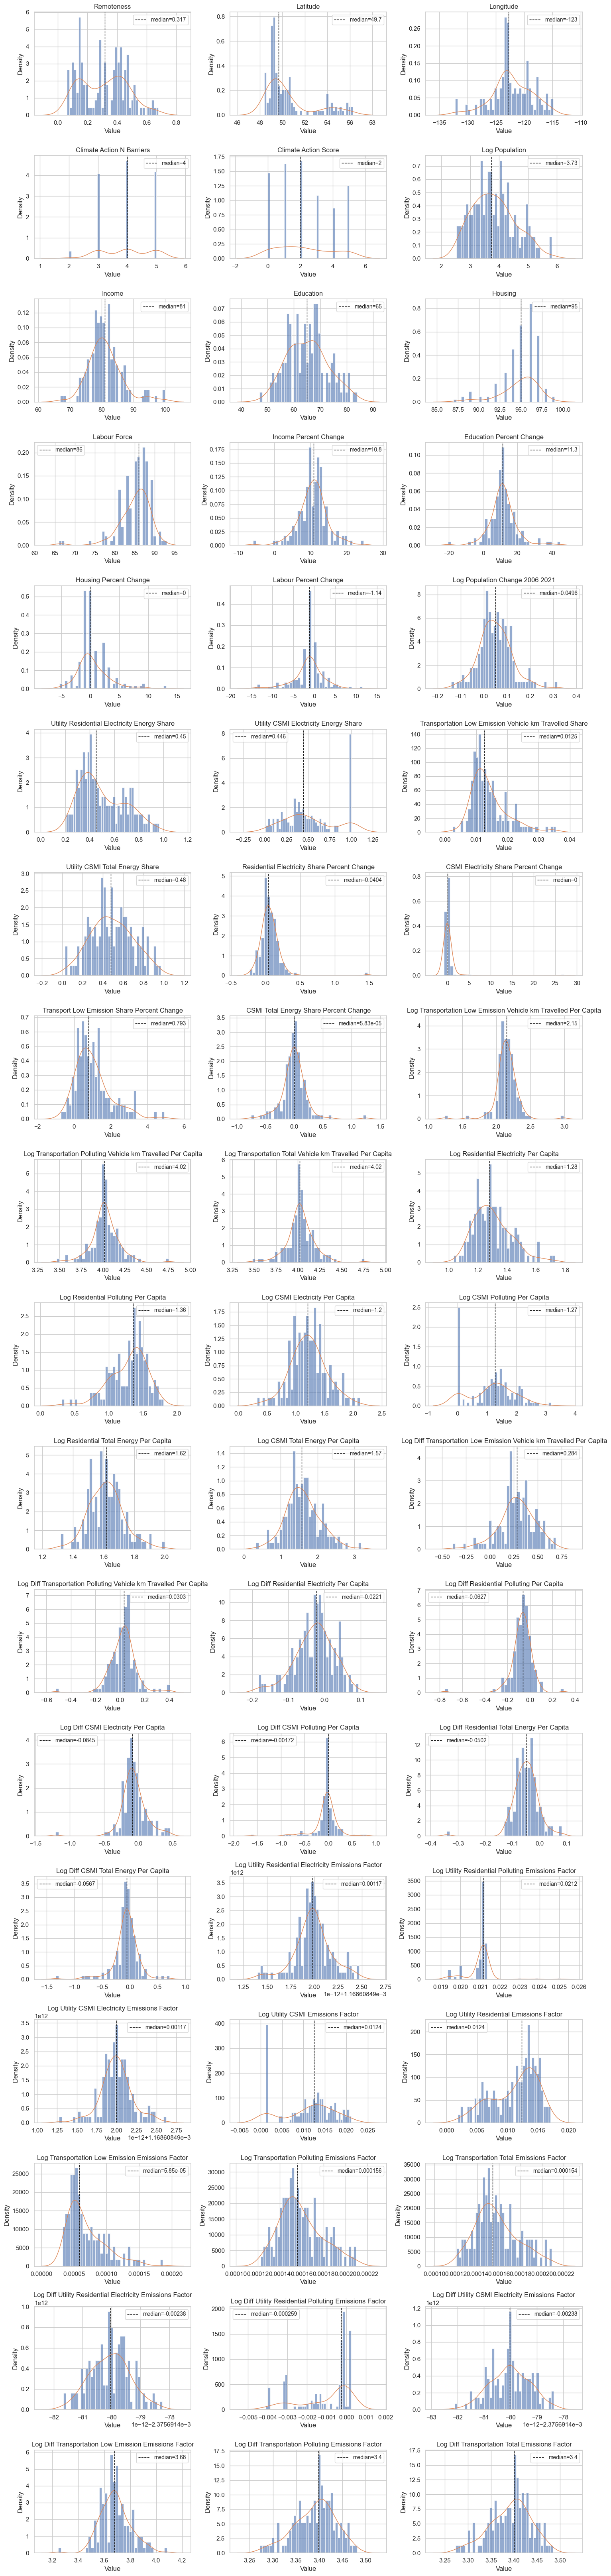

In [ ]:
# Plot histograms for change metrics (paste into your notebook)
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')


features_to_use = [
# Context
    'Remoteness',
    'Latitude',
    'Longitude',
    
    #Climate action
    'Climate_Action_N_Barriers',
    'Climate_Action_Score',
    
    # Socio-economic baseline
    'Log_Population',
    'Income', 'Education', 'Housing', 'Labour_Force', #'CWB',
    
    # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',
    
    # Low-emissions energy shares baseline
    'Utility_Residential_Electricity_Energy_Share',
    'Utility_CSMI_Electricity_Energy_Share',
    'Transportation_Low_Emission_Vehicle_km_Travelled_Share',
    
    # Economic structure baseline
    'Utility_CSMI_Total_Energy_Share', #this is share on total utility enery, not including tranport

    # Energy transition trajectories
    'Residential_Electricity_Share_Percent_Change',
    'CSMI_Electricity_Share_Percent_Change',
    'Transport_Low_Emission_Share_Percent_Change',
    
    # Economic transition trajectories
    'CSMI_Total_Energy_Share_Percent_Change',
    
    # Per capita values for 2021
    'Log_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Log_Transportation_Total_Vehicle_km_Travelled_Per_Capita',
    
    'Log_Residential_Electricity_Per_Capita',
    'Log_Residential_Polluting_Per_Capita',
    'Log_Residential_Total_Energy_Per_Capita',
    
    'Log_CSMI_Electricity_Per_Capita' ,
    'Log_CSMI_Polluting_Per_Capita' ,
    'Log_CSMI_Total_Energy_Per_Capita',
    

    # Per capita changes 2007-2021 (pop from 2006 as a proxy for 2007)
    'Log_Diff_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    'Log_Diff_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Log_Diff_Transportation_Total_Vehicle_km_Travelled_Per_Capita',

    'Log_Diff_Residential_Electricity_Per_Capita',
    'Log_Diff_Residential_Polluting_Per_Capita',
    'Log_Diff_Residential_Total_Energy_Per_Capita',
    
    'Log_Diff_CSMI_Electricity_Per_Capita',
    'Log_Diff_CSMI_Polluting_Per_Capita',
    'Log_Diff_CSMI_Total_Energy_Per_Capita',
    
    # Emission factor end year levels
    'Log_Utility_Residential_Electricity_Emissions_Factor',
    'Log_Utility_Residential_Polluting_Emissions_Factor',
    'Log_Utility_Residential_Emissions_Factor',

    'Log_Utility_CSMI_Electricity_Emissions_Factor',
    'Log_Utility_CSMI_Emissions_Factor',
    
    'Log_Transportation_Low_Emission_Emissions_Factor',
    'Log_Transportation_Polluting_Emissions_Factor',
    'Log_Transportation_Total_Emissions_Factor',
    
    # Emission factor changes 2007-2021
    'Log_Diff_Utility_Residential_Electricity_Emissions_Factor',
    'Log_Diff_Utility_Residential_Polluting_Emissions_Factor',
    'Log_Diff_Utility_CSMI_Electricity_Emissions_Factor',
    #'Log_Diff_Utility_CSMI_Polluting_Emissions_Factor', -> not estimated due to zero divided by zero
    'Log_Diff_Transportation_Low_Emission_Emissions_Factor',
    'Log_Diff_Transportation_Polluting_Emissions_Factor',
    'Log_Diff_Transportation_Total_Emissions_Factor'
    ]

# Keep only rows for the change metrics requested
df = tidy_all_data[tidy_all_data['Metric'].isin(features_to_use)].copy()
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

# remove infinities and extremely large sentinels -- convert to NaN so they are dropped
df['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)
print(df[df['Metric'] == 'Log_Utility_Residential_Electricity_Emissions_Factor']['Year'].unique())
df_2021 = df[df['Year'] == 2021].copy()

# plotting layout
n = len(features_to_use)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.6 * nrows))
axes = axes.flatten()

for ax, metric in zip(axes, features_to_use):
    vals = df_2021.loc[df_2021['Metric'] == metric, 'Value'].dropna()
    if vals.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(metric)
        ax.axis('off')
        continue

    # Plot histogram + KDE
    sns.histplot(vals, bins=40, stat='density', ax=ax, color='C0', edgecolor=None, alpha=0.6)
    try:
        sns.kdeplot(vals, ax=ax, color='C1', lw=1)
    except Exception:
        pass

    # annotate some summary stats
    med = vals.median()
    mean = vals.mean()
    q1, q3 = vals.quantile([0.25, 0.75])
    ax.axvline(med, color='k', linestyle='--', lw=1, label=f'median={med:.3g}')
    ax.set_title(metric.replace('_', ' '))
    ax.legend(fontsize='small')

# hide unused axes
for i in range(n, len(axes)):
    axes[i].axis('off')
# optional: save figure
out_path = '../reports/figures/change_metrics_histograms.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved histogram figure to: {out_path}")
plt.tight_layout()
plt.show()

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/1928679764.py:81: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)


Saved histogram figure to: ../reports/figures/change_metrics_histograms_with_normal.png


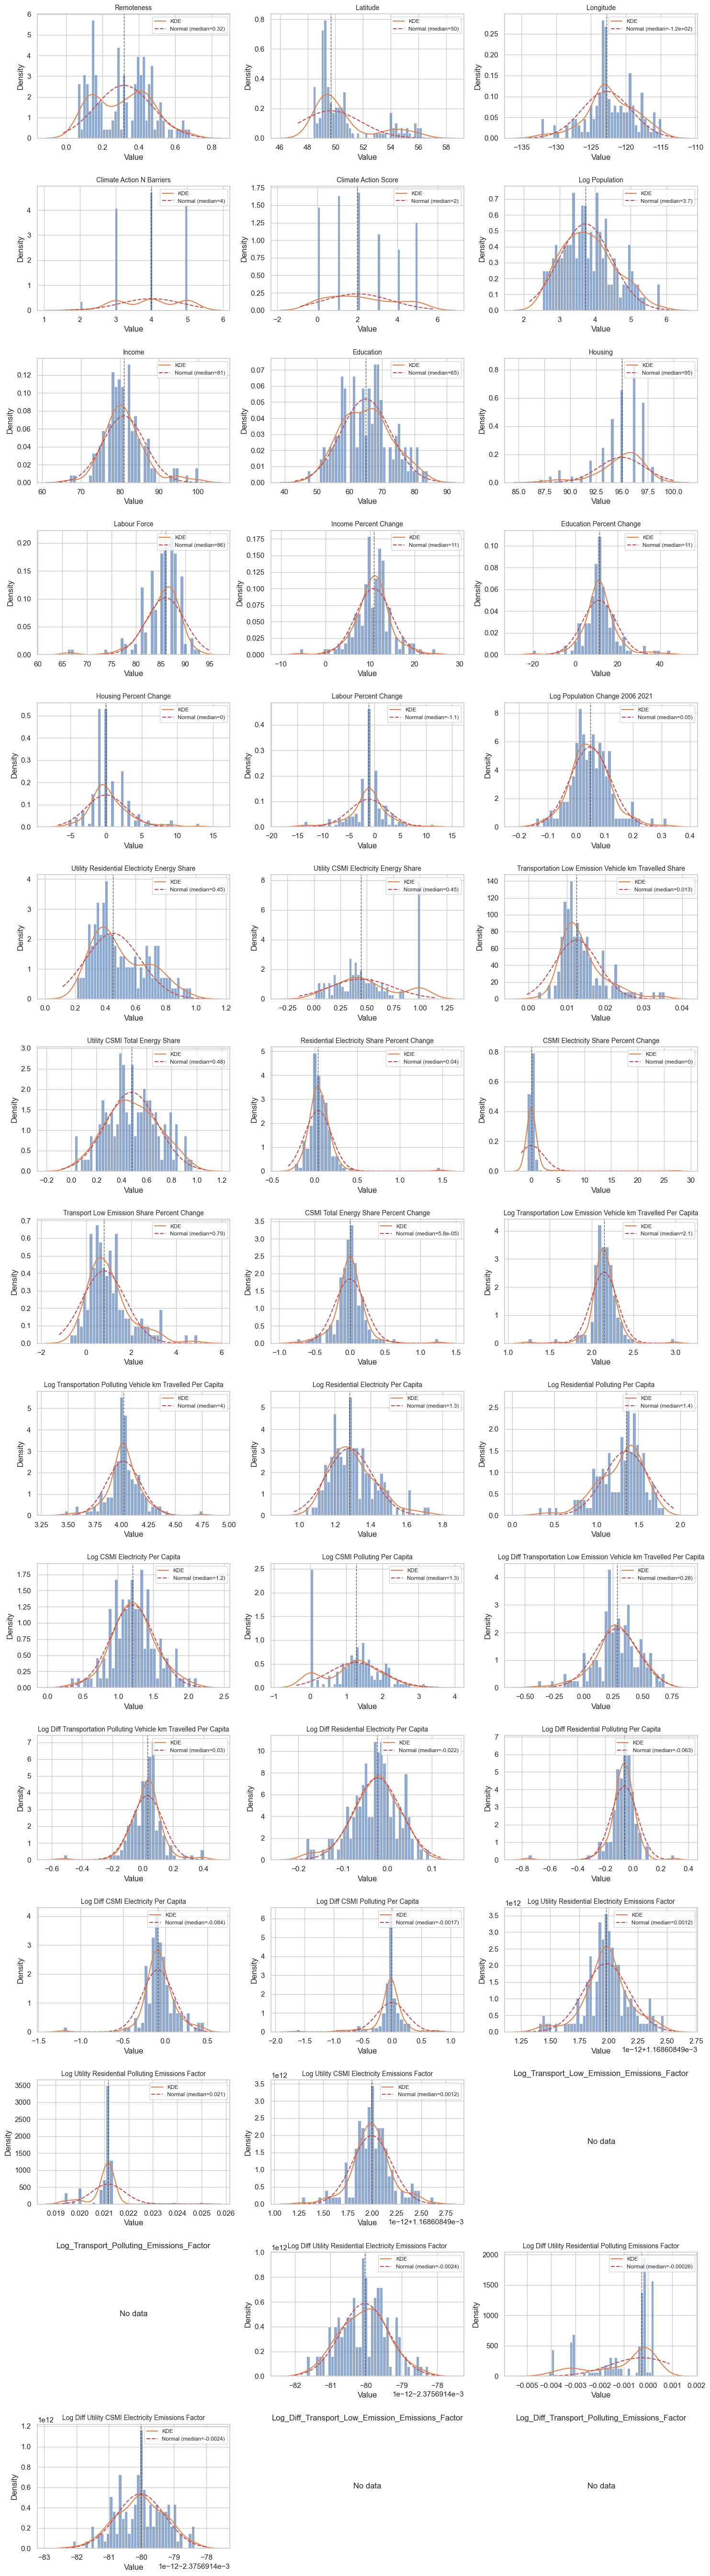

In [114]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set(style='whitegrid')

features_to_use = [
    # Context
    'Remoteness',
    'Latitude',
    'Longitude',
    
    # Climate action
    'Climate_Action_N_Barriers',
    'Climate_Action_Score',
    
    # Socio-economic baseline
    'Log_Population',
    'Income', 'Education', 'Housing', 'Labour_Force',
    
    # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',
    
    # Low-emissions energy shares baseline
    'Utility_Residential_Electricity_Energy_Share',
    'Utility_CSMI_Electricity_Energy_Share',
    'Transportation_Low_Emission_Vehicle_km_Travelled_Share',
    
    # Economic structure baseline
    'Utility_CSMI_Total_Energy_Share',

    # Energy transition trajectories
    'Residential_Electricity_Share_Percent_Change',
    'CSMI_Electricity_Share_Percent_Change',
    'Transport_Low_Emission_Share_Percent_Change',
    
    # Economic transition trajectories
    'CSMI_Total_Energy_Share_Percent_Change',
    
    # Per capita values for 2021
    'Log_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Log_Residential_Electricity_Per_Capita',
    'Log_Residential_Polluting_Per_Capita',
    'Log_CSMI_Electricity_Per_Capita',
    'Log_CSMI_Polluting_Per_Capita',

    # Per capita changes 2007-2021
    'Log_Diff_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    'Log_Diff_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Log_Diff_Residential_Electricity_Per_Capita',
    'Log_Diff_Residential_Polluting_Per_Capita',
    'Log_Diff_CSMI_Electricity_Per_Capita',
    'Log_Diff_CSMI_Polluting_Per_Capita',
    
    # Emission factor end year levels
    'Log_Utility_Residential_Electricity_Emissions_Factor',
    'Log_Utility_Residential_Polluting_Emissions_Factor',
    'Log_Utility_CSMI_Electricity_Emissions_Factor',
    'Log_Transport_Low_Emission_Emissions_Factor',
    'Log_Transport_Polluting_Emissions_Factor',
    
    # Emission factor changes 2007-2021
    'Log_Diff_Utility_Residential_Electricity_Emissions_Factor',
    'Log_Diff_Utility_Residential_Polluting_Emissions_Factor',
    'Log_Diff_Utility_CSMI_Electricity_Emissions_Factor',
    'Log_Diff_Transport_Low_Emission_Emissions_Factor',
    'Log_Diff_Transport_Polluting_Emissions_Factor'
]

# Keep only rows for the change metrics requested
df = tidy_all_data[tidy_all_data['Metric'].isin(features_to_use)].copy()
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

# Remove infinities and extremely large sentinels
df['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_2021 = df[df['Year'] == 2021].copy()

# Plotting layout
n = len(features_to_use)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.6 * nrows))
axes = axes.flatten()

for ax, metric in zip(axes, features_to_use):
    vals = df_2021.loc[df_2021['Metric'] == metric, 'Value'].dropna()
    if vals.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(metric)
        ax.axis('off')
        continue

    # Plot histogram + KDE
    sns.histplot(vals, bins=40, stat='density', ax=ax, color='C0', edgecolor=None, alpha=0.6)
    try:
        sns.kdeplot(vals, ax=ax, color='C1', lw=1.5, label='KDE')
    except Exception:
        pass

    # Compute statistics
    med = vals.median()
    mean = vals.mean()
    std = vals.std()
    
    # Create normal distribution overlay (centered at median, using sample std)
    x_range = np.linspace(vals.min() - 0.5 * std, vals.max() + 0.5 * std, 200)
    
    # Option 1: Normal centered at MEDIAN
    normal_pdf_median = norm.pdf(x_range, loc=med, scale=std)
    ax.plot(x_range, normal_pdf_median, color='C3', linestyle='--', lw=1.5, 
            label=f'Normal (median={med:.2g})')
    
    # Option 2: Uncomment below for normal centered at MEAN instead
    # normal_pdf_mean = norm.pdf(x_range, loc=mean, scale=std)
    # ax.plot(x_range, normal_pdf_mean, color='C2', linestyle=':', lw=1.5, 
    #         label=f'Normal (mean={mean:.2g})')

    ax.axvline(med, color='k', linestyle='--', lw=1, alpha=0.7)
    ax.set_title(metric.replace('_', ' '), fontsize=10)
    ax.legend(fontsize='x-small', loc='upper right')

# Hide unused axes
for i in range(n, len(axes)):
    axes[i].axis('off')

plt.tight_layout()

# Save figure
out_path = '../reports/figures/change_metrics_histograms_with_normal.png'
plt.savefig(out_path, dpi=1000, bbox_inches='tight')
print(f"Saved histogram figure to: {out_path}")
plt.show()

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/1393328872.py:109: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_year['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)


(<Figure size 1200x900 with 2 Axes>,
 <Axes3D: title={'center': 'Trivariate Distribution:\nLatitude × Income × Education'}, xlabel='Latitude', ylabel='Income', zlabel='Education'>,
 <scipy.stats._kde.gaussian_kde at 0x1503b7950>)

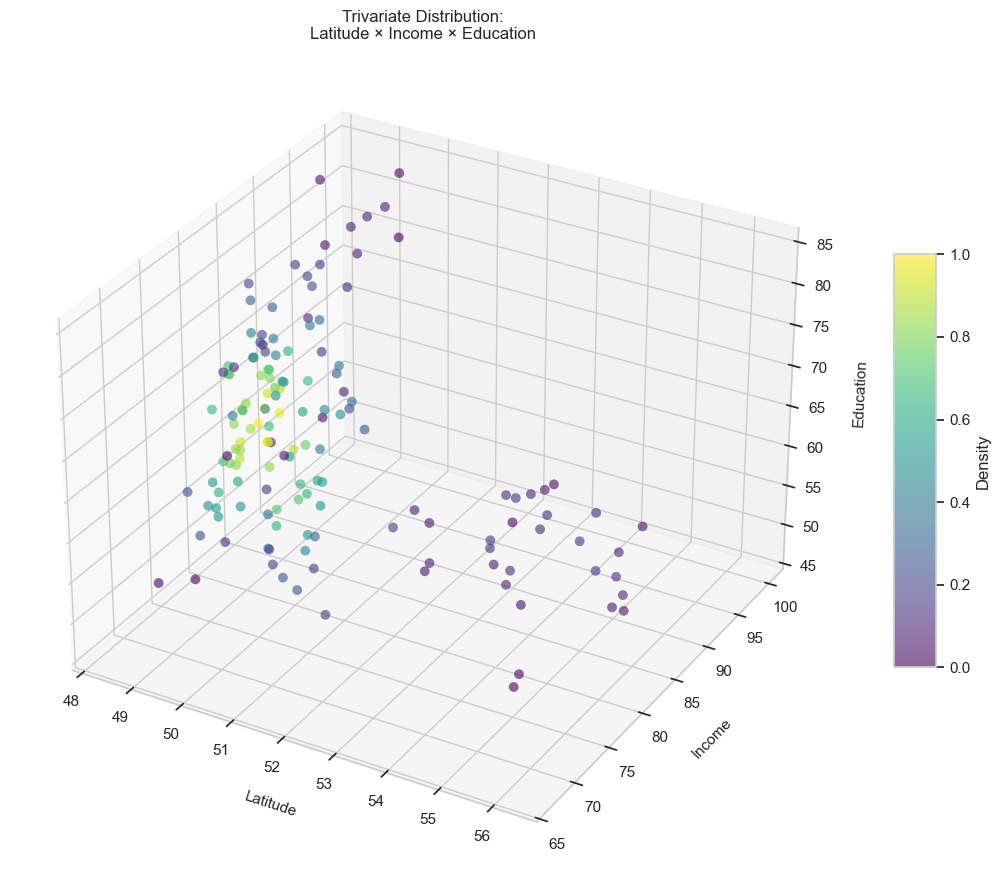

In [115]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
import seaborn as sns

sns.set(style='whitegrid')

def plot_bivariate_density_3d(df, feature_x, feature_y, year=2021, grid_size=100, 
                               figsize=(12, 9), cmap='viridis', alpha=0.8):
    """
    Plot a 3D surface of the bivariate kernel density estimate for two features.
    
    Parameters:
    -----------
    df : DataFrame in tidy format with 'Metric', 'Value', 'Year', and an ID column
    feature_x : str - name of the feature for x-axis
    feature_y : str - name of the feature for y-axis
    year : int - year to filter data
    grid_size : int - resolution of the density grid
    figsize : tuple - figure size
    cmap : str - colormap for the surface
    alpha : float - transparency of the surface
    """
    
    # Filter and pivot data to get both features per municipality
    df_year = df[df['Year'] == year].copy()
    df_year['Value'] = pd.to_numeric(df_year['Value'], errors='coerce')
    df_year['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Pivot to wide format (assuming there's an ID column like 'Municipality' or 'CDUID')
    # Adjust 'index' to match your actual identifier column
    id_col = [c for c in df_year.columns if c not in ['Metric', 'Value', 'Year']][0]
    
    df_wide = df_year.pivot(index=id_col, columns='Metric', values='Value')
    
    # Extract the two features and drop NaNs
    data = df_wide[[feature_x, feature_y]].dropna()
    x = data[feature_x].values
    y = data[feature_y].values
    
    if len(x) < 10:
        print(f"Not enough data points ({len(x)}) for reliable KDE")
        return
    
    # Compute bivariate KDE
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    
    # Create grid for evaluation
    x_margin = (x.max() - x.min()) * 0.1
    y_margin = (y.max() - y.min()) * 0.1
    
    x_grid = np.linspace(x.min() - x_margin, x.max() + x_margin, grid_size)
    y_grid = np.linspace(y.min() - y_margin, y.max() + y_margin, grid_size)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # Evaluate KDE on grid
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)
    
    # Create 3D plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot surface
    surf = ax.plot_surface(X, Y, Z, cmap=cmap, alpha=alpha, 
                           edgecolor='none', antialiased=True)
    
    # Add contour projection on the bottom
    ax.contour(X, Y, Z, zdir='z', offset=0, cmap=cmap, alpha=0.5)
    
    # Labels
    ax.set_xlabel(feature_x.replace('_', ' '), fontsize=10, labelpad=10)
    ax.set_ylabel(feature_y.replace('_', ' '), fontsize=10, labelpad=10)
    ax.set_zlabel('Density', fontsize=10, labelpad=10)
    ax.set_title(f'Bivariate Density:\n{feature_x} vs {feature_y}', fontsize=12)
    
    # Colorbar
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Density')
    
    plt.tight_layout()
    return fig, ax, kde


def plot_trivariate_scatter_density(df, feature_x, feature_y, feature_z, year=2021, 
                                     figsize=(12, 9), cmap='viridis', s=50, alpha=0.6):
    """
    Plot a 3D scatter plot of three features with density-based coloring.
    
    Parameters:
    -----------
    df : DataFrame in tidy format with 'Metric', 'Value', 'Year', and an ID column
    feature_x : str - name of the feature for x-axis
    feature_y : str - name of the feature for y-axis
    feature_z : str - name of the feature for z-axis
    year : int - year to filter data
    figsize : tuple - figure size
    cmap : str - colormap for point coloring
    s : float - scatter point size
    alpha : float - transparency of points
    """
    
    # Filter and pivot data
    df_year = df[df['Year'] == year].copy()
    df_year['Value'] = pd.to_numeric(df_year['Value'], errors='coerce')
    df_year['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)
    
    id_col = [c for c in df_year.columns if c not in ['Metric', 'Value', 'Year']][0]
    df_wide = df_year.pivot(index=id_col, columns='Metric', values='Value')
    
    # Extract the three features and drop NaNs
    data = df_wide[[feature_x, feature_y, feature_z]].dropna()
    x = data[feature_x].values
    y = data[feature_y].values
    z = data[feature_z].values
    
    if len(x) < 10:
        print(f"Not enough data points ({len(x)}) for reliable KDE")
        return
    
    # Compute trivariate KDE for coloring
    xyz = np.vstack([x, y, z])
    kde = gaussian_kde(xyz)
    density = kde(xyz)
    
    # Normalize density for coloring
    density_norm = (density - density.min()) / (density.max() - density.min())
    
    # Create 3D scatter plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Create scatter plot with density-based coloring
    scatter = ax.scatter(x, y, z, c=density_norm, s=s, cmap=cmap, 
                        alpha=alpha, edgecolors='none')
    
    # Labels
    ax.set_xlabel(feature_x.replace('_', ' '), fontsize=11, labelpad=10)
    ax.set_ylabel(feature_y.replace('_', ' '), fontsize=11, labelpad=10)
    ax.set_zlabel(feature_z.replace('_', ' '), fontsize=11, labelpad=10)
    ax.set_title(f'Trivariate Distribution:\n{feature_x} × {feature_y} × {feature_z}', 
                 fontsize=12)
    
    # Colorbar
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label='Density')
    
    plt.tight_layout()
    return fig, ax, kde


def plot_trivariate_multi_view(df, feature_x, feature_y, feature_z, year=2021, 
                                figsize=(16, 5), cmap='viridis', s=50, alpha=0.6):
    """
    Plot three different viewing angles of the trivariate distribution.
    
    Parameters:
    -----------
    df : DataFrame in tidy format
    feature_x, feature_y, feature_z : str - names of features for each axis
    year : int - year to filter data
    figsize : tuple - figure size
    cmap : str - colormap for point coloring
    s : float - scatter point size
    alpha : float - transparency of points
    """
    
    # Filter and pivot data
    df_year = df[df['Year'] == year].copy()
    df_year['Value'] = pd.to_numeric(df_year['Value'], errors='coerce')
    df_year['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)
    
    id_col = [c for c in df_year.columns if c not in ['Metric', 'Value', 'Year']][0]
    df_wide = df_year.pivot(index=id_col, columns='Metric', values='Value')
    
    # Extract the three features and drop NaNs
    data = df_wide[[feature_x, feature_y, feature_z]].dropna()
    x = data[feature_x].values
    y = data[feature_y].values
    z = data[feature_z].values
    
    if len(x) < 10:
        print(f"Not enough data points ({len(x)}) for reliable KDE")
        return
    
    # Compute trivariate KDE for coloring
    xyz = np.vstack([x, y, z])
    kde = gaussian_kde(xyz)
    density = kde(xyz)
    
    # Normalize density for coloring
    density_norm = (density - density.min()) / (density.max() - density.min())
    
    # Create figure with three subplots (different angles)
    fig = plt.figure(figsize=figsize)
    
    angles = [
        (30, 45),    # elevation, azimuth
        (30, 135),
        (30, 225)
    ]
    
    for idx, (elev, azim) in enumerate(angles, 1):
        ax = fig.add_subplot(1, 3, idx, projection='3d')
        
        # Create scatter plot
        scatter = ax.scatter(x, y, z, c=density_norm, s=s, cmap=cmap, 
                            alpha=alpha, edgecolors='none')
        
        # Set viewing angle
        ax.view_init(elev=elev, azim=azim)
        
        # Labels
        ax.set_xlabel(feature_x.replace('_', ' '), fontsize=9, labelpad=8)
        ax.set_ylabel(feature_y.replace('_', ' '), fontsize=9, labelpad=8)
        ax.set_zlabel(feature_z.replace('_', ' '), fontsize=9, labelpad=8)
        ax.set_title(f'View: elev={elev}°, azim={azim}°', fontsize=10)
    
    # Add colorbar
    cbar = fig.colorbar(scatter, ax=fig.axes, shrink=0.6, aspect=15, 
                       label='Density', pad=0.1)
    
    fig.suptitle(f'{feature_x} × {feature_y} × {feature_z} ({year})', 
                fontsize=13, y=0.98)
    plt.tight_layout()
    return fig


def plot_bivariate_with_scatter(df, feature_x, feature_y, year=2021, grid_size=100,
                                 figsize=(14, 5)):
    """
    Create a side-by-side view: 3D density surface + 2D scatter with contours.
    """
    
    # Prepare data (same as above)
    df_year = df[df['Year'] == year].copy()
    df_year['Value'] = pd.to_numeric(df_year['Value'], errors='coerce')
    df_year['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)
    
    id_col = [c for c in df_year.columns if c not in ['Metric', 'Value', 'Year']][0]
    df_wide = df_year.pivot(index=id_col, columns='Metric', values='Value')
    
    data = df_wide[[feature_x, feature_y]].dropna()
    x = data[feature_x].values
    y = data[feature_y].values
    
    if len(x) < 10:
        print(f"Not enough data points ({len(x)}) for reliable KDE")
        return
    
    # KDE
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    
    x_margin = (x.max() - x.min()) * 0.1
    y_margin = (y.max() - y.min()) * 0.1
    
    x_grid = np.linspace(x.min() - x_margin, x.max() + x_margin, grid_size)
    y_grid = np.linspace(y.min() - y_margin, y.max() + y_margin, grid_size)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    
    # Create figure with two subplots
    fig = plt.figure(figsize=figsize)
    
    # 3D surface plot
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
    ax1.contour(X, Y, Z, zdir='z', offset=0, cmap='viridis', alpha=0.5)
    ax1.set_xlabel(feature_x.replace('_', ' '), fontsize=9)
    ax1.set_ylabel(feature_y.replace('_', ' '), fontsize=9)
    ax1.set_zlabel('Density', fontsize=9)
    ax1.set_title('3D Density Surface', fontsize=11)
    
    # 2D scatter + contour plot
    ax2 = fig.add_subplot(122)
    ax2.scatter(x, y, alpha=0.4, s=15, c='steelblue', edgecolor='none')
    contours = ax2.contour(X, Y, Z, levels=10, cmap='Reds')
    ax2.clabel(contours, inline=True, fontsize=8, fmt='%.3f')
    ax2.set_xlabel(feature_x.replace('_', ' '), fontsize=10)
    ax2.set_ylabel(feature_y.replace('_', ' '), fontsize=10)
    ax2.set_title('2D Scatter with Density Contours', fontsize=11)
    
    plt.suptitle(f'{feature_x} vs {feature_y} ({year})', fontsize=13, y=1.02)
    plt.tight_layout()
    return fig


# Example usage for trivariate plots:
# plot_trivariate_scatter_density(tidy_all_data, 'Income_Percent_Change', 'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita', 'Education_Percent_Change', year=2021)
# plot_trivariate_multi_view(tidy_all_data, 'Income_Percent_Change', 'Education_Percent_Change', 'CSMI_Total_Energy_Share_Percent_Change', year=2021)


# Example bivariate usage:
#plot_bivariate_density_3d(tidy_all_data, 'Income', 'Education', year=2021)
#plot_bivariate_with_scatter(tidy_all_data, 'Income_Percent_Change', 'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita', year=2021)
#plot_bivariate_with_scatter(tidy_all_data, 'Education_Percent_Change', 'Income_Percent_Change', year=2021)
#plot_bivariate_with_scatter(tidy_all_data, 'CSMI_Total_Energy_Share_Percent_Change', 'Income_Percent_Change', year=2021)
#plot_bivariate_with_scatter(tidy_all_data, 'Education_Percent_Change', 'CSMI_Total_Energy_Share_Percent_Change', year=2021)
#plot_bivariate_with_scatter(tidy_all_data, 'Latitude', 'Education', year=2021)

# Example trivariate usage (three features):
# Single view
#plot_trivariate_scatter_density(tidy_all_data, 'Income_Percent_Change', 'Education_Percent_Change', 'CSMI_Total_Energy_Share_Percent_Change', year=2021)

plot_trivariate_scatter_density(tidy_all_data, 'Latitude', 'Income', 'Education', year=2021)

# Multiple viewing angles
#plot_trivariate_multi_view(tidy_all_data, 'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita', 'Income_Percent_Change', 'Education_Percent_Change', year=2021)


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/3322017252.py:97: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_year['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12746/3322017252.py:97: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

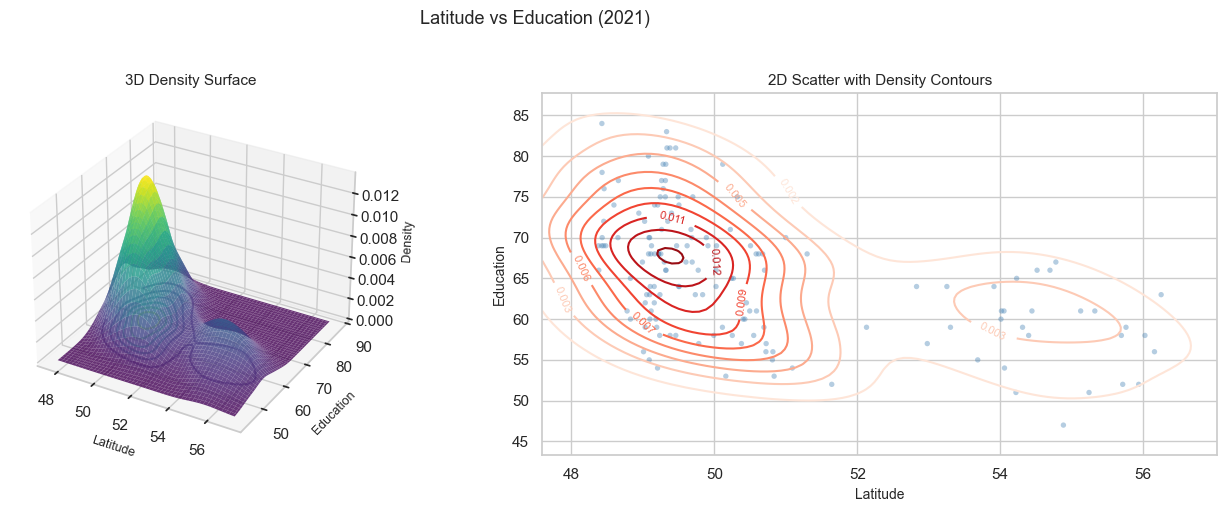

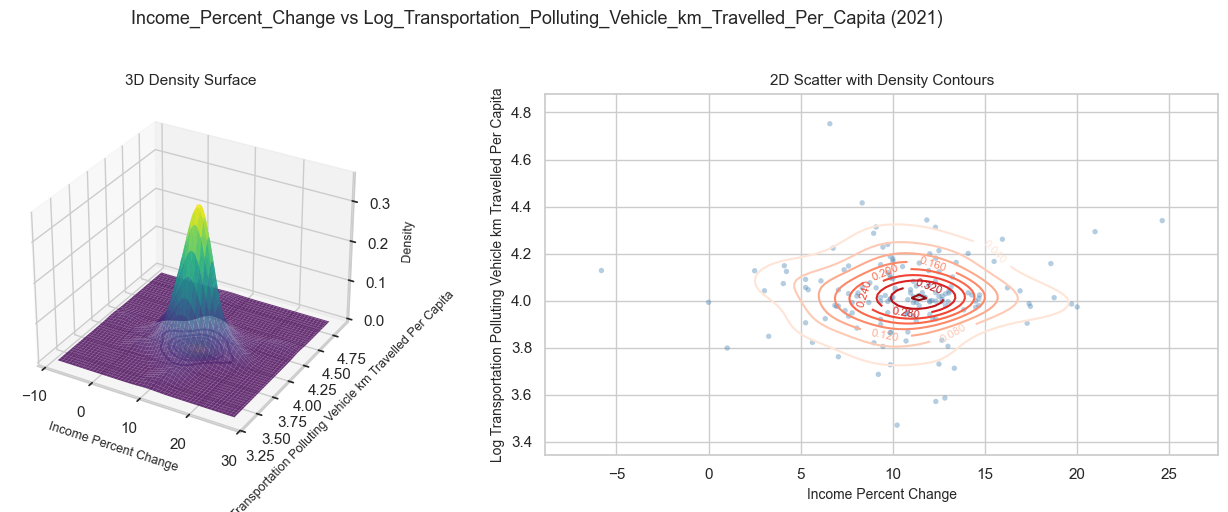

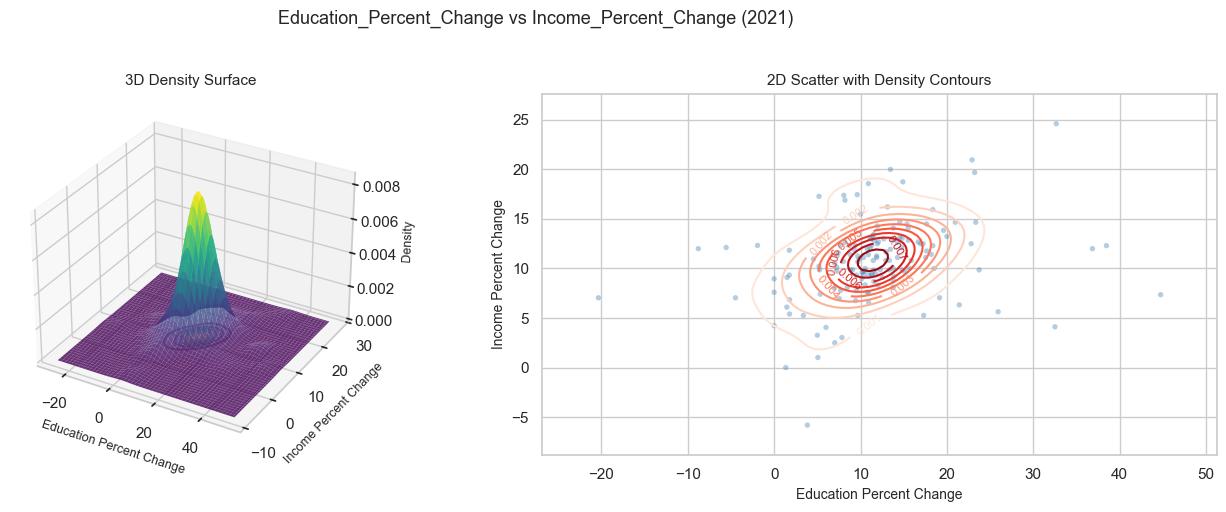

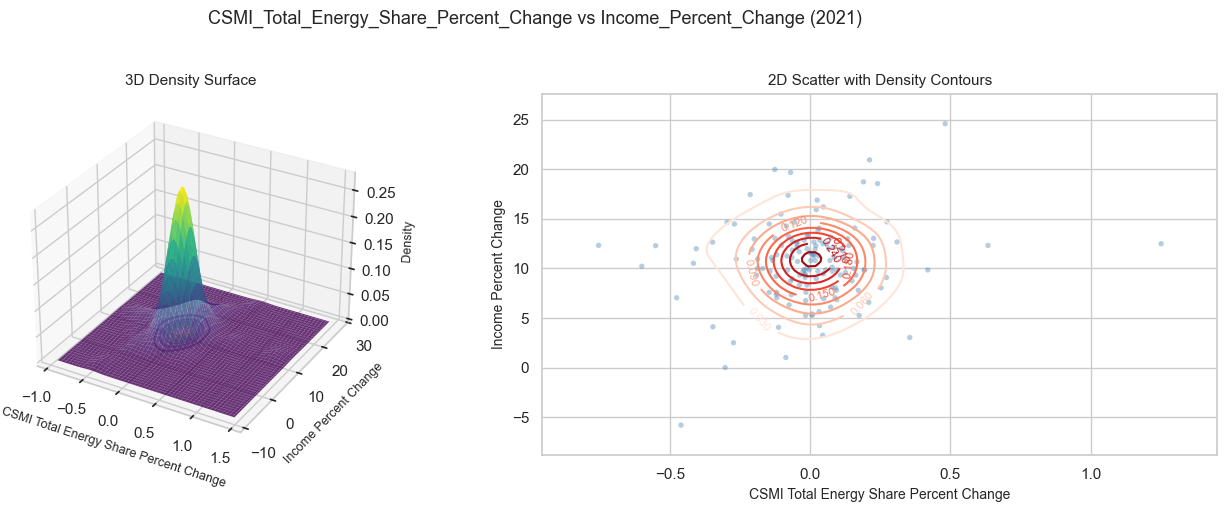

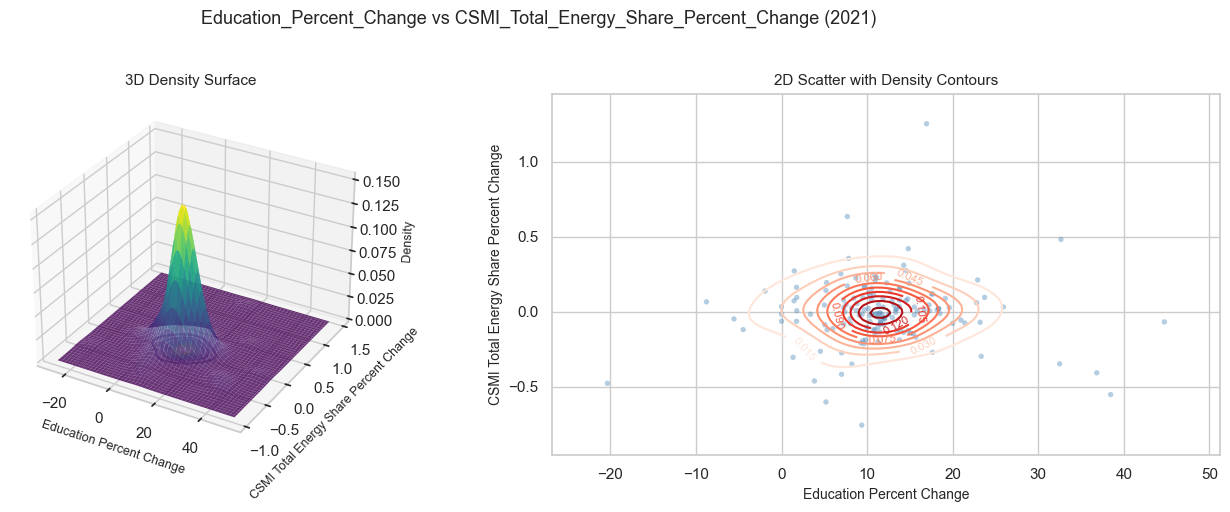

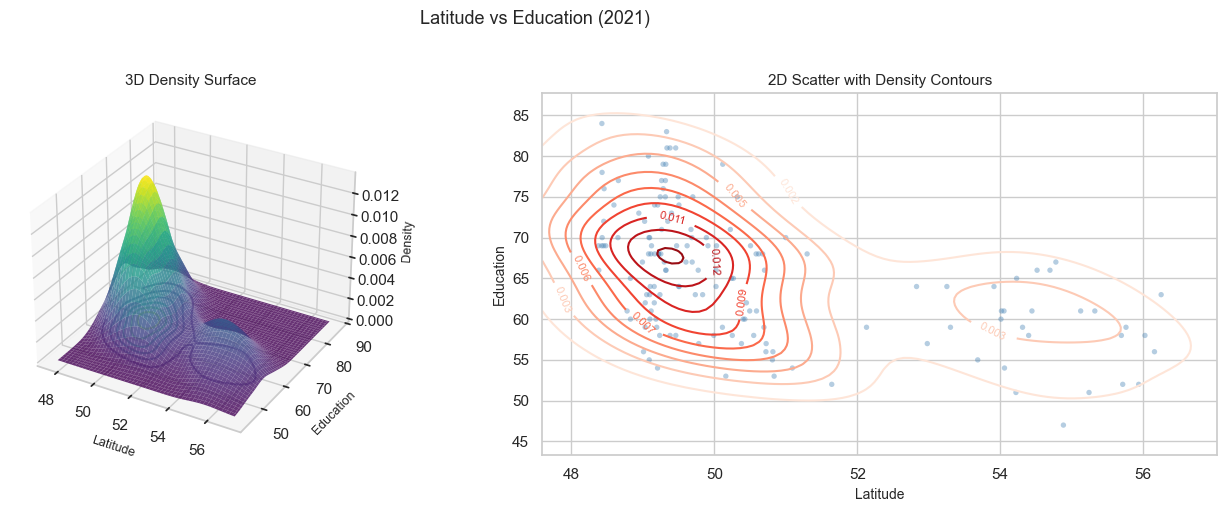

In [116]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
import seaborn as sns

sns.set(style='whitegrid')

def plot_bivariate_density_3d(df, feature_x, feature_y, year=2021, grid_size=100, 
                               figsize=(12, 9), cmap='viridis', alpha=0.8):
    """
    Plot a 3D surface of the bivariate kernel density estimate for two features.
    
    Parameters:
    -----------
    df : DataFrame in tidy format with 'Metric', 'Value', 'Year', and an ID column
    feature_x : str - name of the feature for x-axis
    feature_y : str - name of the feature for y-axis
    year : int - year to filter data
    grid_size : int - resolution of the density grid
    figsize : tuple - figure size
    cmap : str - colormap for the surface
    alpha : float - transparency of the surface
    """
    
    # Filter and pivot data to get both features per municipality
    df_year = df[df['Year'] == year].copy()
    df_year['Value'] = pd.to_numeric(df_year['Value'], errors='coerce')
    df_year['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Pivot to wide format (assuming there's an ID column like 'Municipality' or 'CDUID')
    # Adjust 'index' to match your actual identifier column
    id_col = [c for c in df_year.columns if c not in ['Metric', 'Value', 'Year']][0]
    
    df_wide = df_year.pivot(index=id_col, columns='Metric', values='Value')
    
    # Extract the two features and drop NaNs
    data = df_wide[[feature_x, feature_y]].dropna()
    x = data[feature_x].values
    y = data[feature_y].values
    
    if len(x) < 10:
        print(f"Not enough data points ({len(x)}) for reliable KDE")
        return
    
    # Compute bivariate KDE
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    
    # Create grid for evaluation
    x_margin = (x.max() - x.min()) * 0.1
    y_margin = (y.max() - y.min()) * 0.1
    
    x_grid = np.linspace(x.min() - x_margin, x.max() + x_margin, grid_size)
    y_grid = np.linspace(y.min() - y_margin, y.max() + y_margin, grid_size)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # Evaluate KDE on grid
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)
    
    # Create 3D plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot surface
    surf = ax.plot_surface(X, Y, Z, cmap=cmap, alpha=alpha, 
                           edgecolor='none', antialiased=True)
    
    # Add contour projection on the bottom
    ax.contour(X, Y, Z, zdir='z', offset=0, cmap=cmap, alpha=0.5)
    
    # Labels
    ax.set_xlabel(feature_x.replace('_', ' '), fontsize=10, labelpad=10)
    ax.set_ylabel(feature_y.replace('_', ' '), fontsize=10, labelpad=10)
    ax.set_zlabel('Density', fontsize=10, labelpad=10)
    ax.set_title(f'Bivariate Density:\n{feature_x} vs {feature_y}', fontsize=12)
    
    # Colorbar
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Density')
    
    plt.tight_layout()
    return fig, ax, kde


def plot_bivariate_with_scatter(df, feature_x, feature_y, year=2021, grid_size=100,
                                 figsize=(14, 5)):
    """
    Create a side-by-side view: 3D density surface + 2D scatter with contours.
    """
    
    # Prepare data (same as above)
    df_year = df[df['Year'] == year].copy()
    df_year['Value'] = pd.to_numeric(df_year['Value'], errors='coerce')
    df_year['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)
    
    id_col = [c for c in df_year.columns if c not in ['Metric', 'Value', 'Year']][0]
    df_wide = df_year.pivot(index=id_col, columns='Metric', values='Value')
    
    data = df_wide[[feature_x, feature_y]].dropna()
    x = data[feature_x].values
    y = data[feature_y].values
    
    if len(x) < 10:
        print(f"Not enough data points ({len(x)}) for reliable KDE")
        return
    
    # KDE
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    
    x_margin = (x.max() - x.min()) * 0.1
    y_margin = (y.max() - y.min()) * 0.1
    
    x_grid = np.linspace(x.min() - x_margin, x.max() + x_margin, grid_size)
    y_grid = np.linspace(y.min() - y_margin, y.max() + y_margin, grid_size)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    
    # Create figure with two subplots
    fig = plt.figure(figsize=figsize)
    
    # 3D surface plot
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
    ax1.contour(X, Y, Z, zdir='z', offset=0, cmap='viridis', alpha=0.5)
    ax1.set_xlabel(feature_x.replace('_', ' '), fontsize=9)
    ax1.set_ylabel(feature_y.replace('_', ' '), fontsize=9)
    ax1.set_zlabel('Density', fontsize=9)
    ax1.set_title('3D Density Surface', fontsize=11)
    
    # 2D scatter + contour plot
    ax2 = fig.add_subplot(122)
    ax2.scatter(x, y, alpha=0.4, s=15, c='steelblue', edgecolor='none')
    contours = ax2.contour(X, Y, Z, levels=10, cmap='Reds')
    ax2.clabel(contours, inline=True, fontsize=8, fmt='%.3f')
    ax2.set_xlabel(feature_x.replace('_', ' '), fontsize=10)
    ax2.set_ylabel(feature_y.replace('_', ' '), fontsize=10)
    ax2.set_title('2D Scatter with Density Contours', fontsize=11)
    
    plt.suptitle(f'{feature_x} vs {feature_y} ({year})', fontsize=13, y=1.02)
    plt.tight_layout()
    return fig


# Example usage:
#plot_bivariate_density_3d(tidy_all_data, 'Income', 'Education', year=2021)
plot_bivariate_with_scatter(tidy_all_data, 'Income_Percent_Change', 'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita', year=2021)
plot_bivariate_with_scatter(tidy_all_data, 'Education_Percent_Change', 'Income_Percent_Change', year=2021)
plot_bivariate_with_scatter(tidy_all_data, 'CSMI_Total_Energy_Share_Percent_Change', 'Income_Percent_Change', year=2021)
plot_bivariate_with_scatter(tidy_all_data, 'Education_Percent_Change', 'CSMI_Total_Energy_Share_Percent_Change', year=2021)

plot_bivariate_with_scatter(tidy_all_data, 'Latitude', 'Education', year=2021)


In [117]:
#get only tidy wellbeing data
tidy_wellbeing

,Municipality_Name,Year,Metric,Value,Unit
0,Elkford,2006,CWB,80.000000,index
1,Sparwood,2006,CWB,78.000000,index
2,Fernie,2006,CWB,80.000000,index
3,Cranbrook,2006,CWB,78.000000,index
4,Kimberley,2006,CWB,78.000000,index
...,...,...,...,...,...
4258,Chetwynd,2021,Population_Percent_Change,-12.571212,percent
4259,Dawson Creek,2021,Population_Percent_Change,12.088412,percent
4260,Hudson's Hope,2021,Population_Percent_Change,-16.897233,percent
4261,Taylor,2021,Population_Percent_Change,-4.841040,percent
